# NLP Assignment

This notebook works on the Twitter US Airline Sentiment tweets (Kaggle). It covers preprocessing (Task 1), a TF-IDF baseline (Task 2), sentence embeddings (Task 3), a fine-tuned DistilBERT (Task 4) and the checks for the responsible NLP discussion (Task 5). Run it from top to bottom. Only Task 4 needs a GPU(T4 Runtime type).

Imports, NLTK data, the spaCy model and a few settings. The RandomSeed everywhere should be 42 .

In [ ]:
# if something is missing please uncomment this two lines and run them first

# !pip install -q kagglehub sentence-transformers wordcloud
# !python -m spacy download en_core_web_sm

import warnings
warnings.filterwarnings("ignore")

import re, os, glob, html, time, random
from collections import Counter
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import TreebankWordTokenizer, TweetTokenizer

# NLTK data and the small English spaCy model
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nlp = spacy.load("en_core_web_sm")

# as I said before,to give the same results for every rerun we put 42 in seed everywhere
seed = 42
random.seed(seed)
np.random.seed(seed)

# Fixing the size of the charts and tables
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 12, "axes.titleweight": "bold"})

# class order and colors used in every chart
Class_Orders = ["negative", "neutral", "positive"]
COLORS = {"negative": "#D55E00", "neutral": "#7F7F7F", "positive": "#0072B2"}

# prints the title first and then the table
def show(table, title=None):
    if title:
        print(title)
    display(table)

# Task 1: Preprocessing and exploratory analysis

### 1.1 Load the data

The csv was downloaded from Kaggle website with "kagglehub" order, and only the useful columns later will be kept.

In [ ]:
import kagglehub

# download from Kaggle
downloaded_File = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
# the folder has a csv and an sqlite file, we just need the CSV
csv_File = glob.glob(os.path.join(downloaded_File, "**", "*.csv"), recursive=True)[0]
rawCsvFile = pd.read_csv(csv_File)
print(os.path.basename(csv_File), rawCsvFile.shape)

# we just keep the useful columns
needed_columns = ["tweet_id", "airline", "airline_sentiment", "airline_sentiment_confidence",
        "negativereason", "negativereason_confidence", "text", "tweet_created"]
raw_data_Frame = rawCsvFile[[n_c for n_c in needed_columns if n_c in rawCsvFile.columns]].copy()
show(raw_data_Frame.head(5))

Using Colab cache for faster access to the 'twitter-airline-sentiment' dataset.
Tweets.csv (14640, 15)


,tweet_id,airline,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,text,tweet_created
0,570306133677760513,Virgin America,neutral,1.0000,NaN,NaN,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800
1,570301130888122368,Virgin America,positive,0.3486,NaN,0.0000,@VirginAmerica plus you've added commercials to the experience... tacky.,2015-02-24 11:15:59 -0800
2,570301083672813571,Virgin America,neutral,0.6837,NaN,NaN,@VirginAmerica I didn't today... Must mean I need to take another trip!,2015-02-24 11:15:48 -0800
3,570301031407624196,Virgin America,negative,1.0000,Bad Flight,0.7033,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",2015-02-24 11:15:36 -0800
4,570300817074462722,Virgin America,negative,1.0000,Can't Tell,1.0000,@VirginAmerica and it's a really big bad thing about it,2015-02-24 11:14:45 -0800


### 1.2 Inspect the examples and remove duplicates

Column types and missing values first. Then repeated texts: the same tweet could end up in both train and test, so only the first copy is kept.

In [ ]:
# data type and missing values of each column
dataTypes_missingValues = pd.DataFrame({"Data type": raw_data_Frame.dtypes.astype(str), "Missing values": raw_data_Frame.isna().sum(),
                       "Missing values %": (raw_data_Frame.isna().mean() * 100).round(1)})
show(dataTypes_missingValues, "Columns:")

# keep=False means it will marks every copy, then texts with different labels can be found as well
repeated = raw_data_Frame[raw_data_Frame["text"].duplicated(keep=False)]
n_conflict = (repeated.groupby("text")["airline_sentiment"].nunique() > 1).sum()
print("Duplicate texts:", raw_data_Frame["text"].duplicated().sum(), "| of them with different labels:", n_conflict)

# we just keep the first copy,then as a result one tweet cannot be in both train and test
# the reset_index gives new row numbers 0 to n-1
n_before = len(raw_data_Frame)
raw_data_Frame = raw_data_Frame.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Rows: {n_before} ==> {len(raw_data_Frame)}")

Columns:


,Data type,Missing values,Missing values %
tweet_id,int64,0,0.0
airline,object,0,0.0
airline_sentiment,object,0,0.0
airline_sentiment_confidence,float64,0,0.0
negativereason,object,5462,37.3
negativereason_confidence,float64,4118,28.1
text,object,0,0.0
tweet_created,object,0,0.0


Duplicate texts: 213 | of them with different labels: 25
Rows: 14640 ==> 14427


In [ ]:
# 3 random tweet per class
for s in Class_Orders:
    print(f"\n{s.upper()} : ")
    for t in raw_data_Frame[raw_data_Frame["airline_sentiment"] == s].sample(3, random_state=seed)["text"]:
        print("*", t)


NEGATIVE : 
* @united why do you hire POS pilots? Thanks for ruining my trip and not allowing me to see my buddy as he turns 30. #unitedsucksdick
* @USAirways thank you for blowing my vacation. Couldn't get me anywhere today to make my reservation and also lost 2 bags of mine!
* @united Stopped flying @united 1 yr ago bc of aggressive policy on carryon @bdl listening to pssngrs forced to chk@preboard,#notcomingback

NEUTRAL : 
* @JetBlue such a bummer.  But I understand it's a business deal. Thanks for answering me!  Much less sad now.
* @united I guess that's too much ask, huh?
* @SouthwestAir #DestinationDragons Any word on winners of contest? Any chance for tix for the Provo DestinationDragons show? Fingers Crossed!

POSITIVE : 
* @AmericanAir thanks to Jacqueline in CLT for cleaning up @amexserve and @USAirways mess!!! Awesome service
* @JetBlue  hahah 😂👌👌👌 love flying jet blue tho!! http://t.co/7VeE44MACM
* @JetBlue sounds good!!!💙💙💙💙


### 1.3 Exploratory analysis

Class balance, the reasons behind negative tweets, and tweet length.

Class distribution:


,Tweets,%
airline_sentiment,,
negative,9080,62.9
neutral,3057,21.2
positive,2290,15.9


Largest / smallest class: 3.97 | majority-class accuracy: 0.629


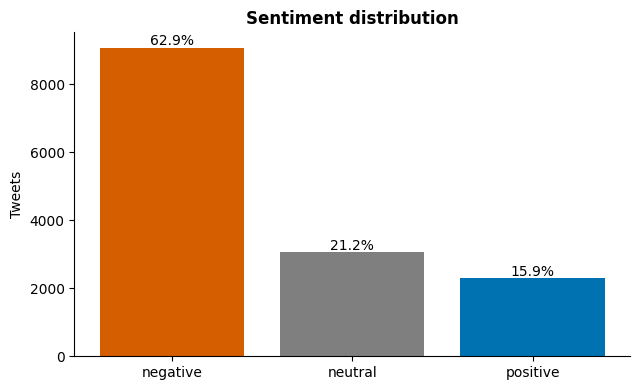

In [ ]:
# reindex(ClassOrders) keeps the classes in the same order everywhere
counts = raw_data_Frame["airline_sentiment"].value_counts().reindex(Class_Orders)
pct = (counts / len(raw_data_Frame) * 100).round(1)
show(pd.DataFrame({"Tweets": counts, "%": pct}), "Class distribution:")
# imbalance ratio, and the accuracy we get by always guessing the biggest class
print(f"Largest / smallest class: {counts.max() / counts.min():.2f} | majority-class accuracy: {counts.max() / len(raw_data_Frame):.3f}")

# bar chart with the percentage above each bar
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(counts.index, counts.values, color=[COLORS[s] for s in Class_Orders])
for b, p in zip(bars, pct):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 80, f"{p}%", ha="center")
ax.set(title="Sentiment distribution", ylabel="Tweets")
plt.tight_layout(); plt.show()

Tweets per airline, and the share of each sentiment inside every airline.

Tweets per airline and sentiment:


airline_sentiment,negative,neutral,positive,Total
airline,,,,
United,2633,694,478,3805
US Airways,2262,380,264,2906
American,1864,431,299,2594
Southwest,1185,658,565,2408
Delta,955,723,533,2211
Virgin America,181,171,151,503


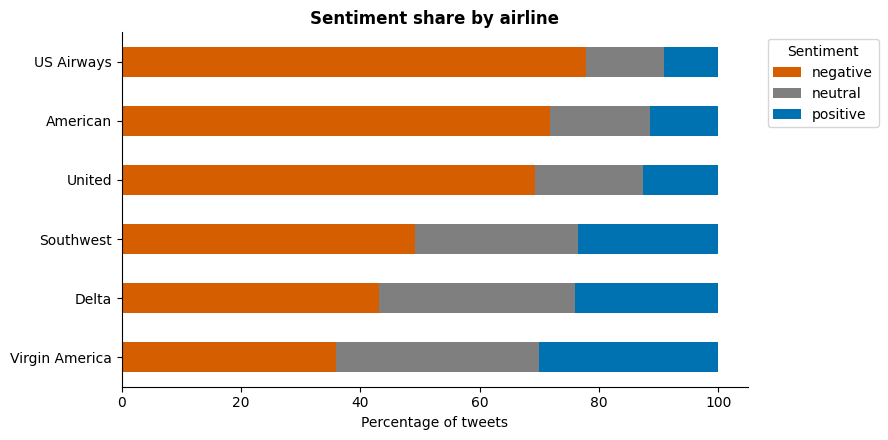

In [ ]:
# tweets per airline and sentiment, in addition to the total of them
airlineCounts = pd.crosstab(raw_data_Frame["airline"], raw_data_Frame["airline_sentiment"])[Class_Orders]
airlineCounts["Total"] = airlineCounts.sum(axis=1)
show(airlineCounts.sort_values("Total", ascending=False), "Tweets per airline and sentiment:")

# share of each sentiment inside every airline, sorted by the share of negative tweets
airline_pct = pd.crosstab(raw_data_Frame["airline"], raw_data_Frame["airline_sentiment"], normalize="index")[Class_Orders] * 100
airline_pct = airline_pct.sort_values("negative")
ax = airline_pct.plot(kind="barh", stacked=True, figsize=(9, 4.5), color=[COLORS[s] for s in Class_Orders])
ax.set(title="Sentiment share by airline", xlabel="Percentage of tweets", ylabel="")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

Negative tweets without a reason: 0.0%
Complaint reasons:


,Tweets,%
negativereason,,
Customer Service Issue,2883,31.8
Late Flight,1650,18.2
Can't Tell,1176,13.0
Cancelled Flight,829,9.1
Lost Luggage,719,7.9
Bad Flight,575,6.3
Flight Booking Problems,523,5.8
Flight Attendant Complaints,475,5.2
longlines,177,1.9


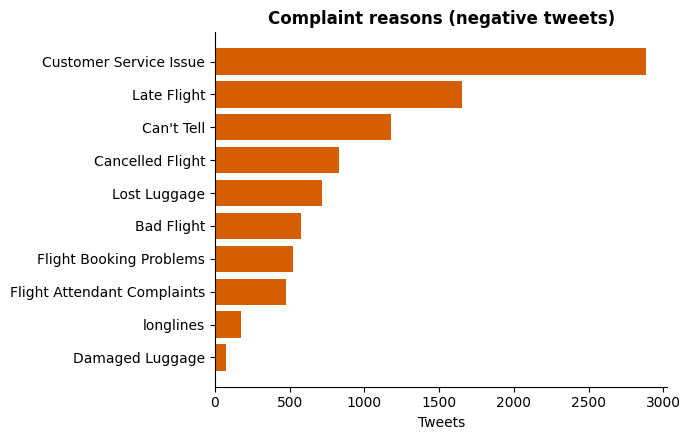

In [ ]:
# How many negative tweets have no reason ? (0% means the table below covers all of them correctly)
neg = raw_data_Frame[raw_data_Frame["airline_sentiment"] == "negative"]
print(f"Negative tweets without a reason: {neg['negativereason'].isna().mean() * 100:.1f}%")
reasons = neg["negativereason"].value_counts()
show(pd.DataFrame({"Tweets": reasons, "%": (reasons / reasons.sum() * 100).round(1)}), "Complaint reasons:")

# [::-1] puts the biggest reason at the top
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(reasons.index[::-1], reasons.values[::-1], color=COLORS["negative"])
ax.set(title="Complaint reasons (negative tweets)", xlabel="Tweets")
plt.tight_layout(); plt.show()

Tweet length by class:


n_chars             n_words           
                     mean median  max    mean median max
airline_sentiment                                       
negative            113.9  126.0  176    19.7   21.0  36
neutral              87.6   88.0  167    14.4   14.0  31
positive             87.6   88.0  186    14.3   14.0  31

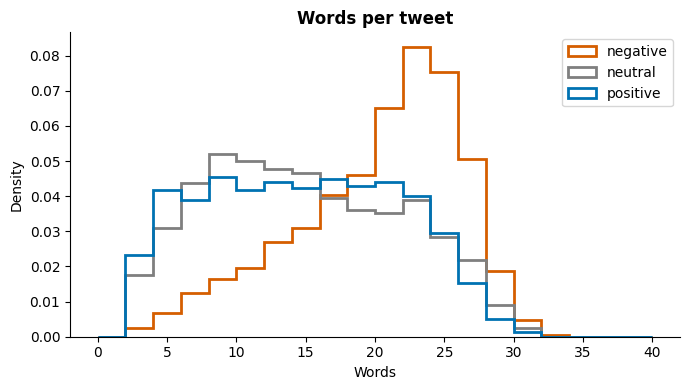

In [ ]:
# length in characters and in words
raw_data_Frame["n_chars"] = raw_data_Frame["text"].str.len()
raw_data_Frame["n_words"] = raw_data_Frame["text"].str.split().str.len()
show(raw_data_Frame.groupby("airline_sentiment")[["n_chars", "n_words"]].agg(["mean", "median", "max"]).round(1).reindex(Class_Orders),
     "Tweet length by class:")

# density instaed of counts, just because the classes have different sizes
fig, ax = plt.subplots(figsize=(7, 4))
for s in Class_Orders:
    ax.hist(raw_data_Frame.loc[raw_data_Frame["airline_sentiment"] == s, "n_words"], bins=range(0, 41, 2),
            histtype="step", linewidth=2, density=True, label=s, color=COLORS[s])
ax.set(title="Words per tweet", xlabel="Words", ylabel="Density")
ax.legend()
plt.tight_layout(); plt.show()

How sure the annotators were about each label, per class (1.0 means all annotators agreed).

In [ ]:
# annotator confidence per class: mean, share with full agreement, share below 0.7
conf_table = (raw_data_Frame.groupby("airline_sentiment")["airline_sentiment_confidence"]
              .agg(mean_conf="mean", full=lambda s: (s == 1.0).mean() * 100, low=lambda s: (s < 0.7).mean() * 100)
              .round(2).reindex(Class_Orders))
conf_table.columns = [" Mean confidence", "      % with full agreement", "       % below 0.7"]
show(conf_table, "Annotator confidence by sentiment:")

Annotator confidence by sentiment:


,Mean confidence,% with full agreement,% below 0.7
airline_sentiment,,,
negative,0.93,80.40,17.76
neutral,0.82,49.85,47.37
positive,0.87,64.15,32.93


### 1.4 Basic text cleaning

Tweets are full of mentions, links, hashtags and stretched words. `CleaningTheTweets` turns them into plain lowercase text for the classical models. Contractions are written out (`don't` becomes `do not`), so negation stays visible. Stop words are not touched here, see 1.6.

In [ ]:
def CleaningTheTweets(text):
    # unescape first, otherwise "&amp;" would leave a fake word "amp"
    text = html.unescape(text).lower().replace("’", "'")
    # links become just one token ==> url
    text = re.sub(r"https?://\S+|www\.\S+", " url ", text)
    # mentions are removed
    text = re.sub(r"@\w+", " ", text)
    # hashtag: drop the # sign, keep the word
    text = re.sub(r"#(\w+)", r"\1", text)
    # can't and won't go first, the n't rule would turn them into "ca not" and "wo not"
    text = text.replace("can't", "cannot").replace("won't", "will not")
    # other contractions are written out, so negation stays visible
    text = re.sub(r"n't\b", " not", text)
    for short, full in [("'ve", " have"), ("'ll", " will"), ("'re", " are"), ("'m", " am"), ("'d", " would")]:
        text = re.sub(short + r"\b", full, text)
    # 's is dropped (it can mean "is" or "of")
    text = re.sub(r"'s\b", "", text)
    # keep only letters and digits
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # sooooo -> soo
    text = re.sub(r"([a-z])\1{2,}", r"\1\1", text)
    return re.sub(r"\s+", " ", text).strip()

# four made-up tweets with typical problems
examples = [
    "@united I can't believe my flight got cancelled AGAIN!!! #fail https://t.co/abc123 😡",
    "@AmericanAir thanks for the sooo helpful crew :)",
    "@SouthwestAir I didn't get my bag... waiting 2000 mins",
    "@united thanks for the delay &amp; the lost bag, we've waited 3 hrs -&gt; it's unacceptable",
]

#comparing them
for t in examples:
    print("Original:", t)
    print("Cleaned: ", CleaningTheTweets(t), "\n")

Original: @united I can't believe my flight got cancelled AGAIN!!! #fail https://t.co/abc123 😡
Cleaned:  i cannot believe my flight got cancelled again fail url 

Original: @AmericanAir thanks for the sooo helpful crew :)
Cleaned:  thanks for the soo helpful crew 

Original: @SouthwestAir I didn't get my bag... waiting 2000 mins
Cleaned:  i did not get my bag waiting 2000 mins 

Original: @united thanks for the delay &amp; the lost bag, we've waited 3 hrs -&gt; it's unacceptable
Cleaned:  thanks for the delay the lost bag we have waited 3 hrs it unacceptable 



In [ ]:
# clean each tweet
# a few tweets will be empty bcs they just include a link or mentions,  then they will be dropped
raw_data_Frame["clean_text"] = raw_data_Frame["text"].apply(CleaningTheTweets)
n_empty = (raw_data_Frame["clean_text"] == "").sum()
raw_data_Frame = raw_data_Frame[raw_data_Frame["clean_text"] != ""].reset_index(drop=True)
print("Empty after cleaning:", n_empty, "| tweets kept:", len(raw_data_Frame))
show(raw_data_Frame[["text", "clean_text"]].sample(5, random_state=seed), "Original vs cleaned:")

Empty after cleaning: 0 | tweets kept: 14427
Original vs cleaned:


,text,clean_text
8757,@JetBlue so technically I could drive to JFK now and put in. Request for tomorrow's flight?,so technically i could drive to jfk now and put in request for tomorrow flight
2807,@united why I won't check my carry on. Watched a handler throw this bag -- miss the conveyer belt -- sat there 10 min http://t.co/lyoocx5mSH,why i will not check my carry on watched a handler throw this bag miss the conveyer belt sat there 10 min url
6071,@SouthwestAir you guys are so clever 😃 http://t.co/qn5odUGFqK,you guys are so clever url
11098,@USAirways a year and every time with US Air something happens. I sat waiting for a re-scheduled flight for 10 hours then to say its,a year and every time with us air something happens i sat waiting for a re scheduled flight for 10 hours then to say its
3014,@united 2nd time in a row I've been over charged by 100's of $$ on my plane ticket WHY? #united I shouldn't have to check my CC everytime,2nd time in a row i have been over charged by 100 of on my plane ticket why united i should not have to check my cc everytime


### 1.5 Tokenization

Tweets are processed using four tokenizers: whitespace splitting, and the NLTK and spaCy tokenizers. The resulting tokens demonstrate how each of these methods handles mentions, emoticons, hashtags, and links.

In [ ]:
# same tweet, four tokenisers (make_doc only splits into tokens, nothing else)
example = "@united my flight was delayed AGAIN!!! can't believe it :( #fail https://t.co/abc123"
tokens = {
    "Whitespace": example.split(),
    "NLTK Treebank": TreebankWordTokenizer().tokenize(example),
    "NLTK TweetTokenizer": TweetTokenizer().tokenize(example),
    "spaCy": [t.text for t in nlp.make_doc(example)],
}
show(pd.DataFrame({"Tokens": list(tokens.values()), "Count": [len(v) for v in tokens.values()]},
                  index=list(tokens.keys())), "Same tweet, four tokenisers:")

Same tweet, four tokenisers:


,Tokens,Count
Whitespace,"[@united, my, flight, was, delayed, AGAIN!!!, can't, believe, it, :(, #fail, https://t.co/abc123]",12
NLTK Treebank,"[@, united, my, flight, was, delayed, AGAIN, !, !, !, ca, n't, believe, it, :, (, #, fail, https, :, //t.co/abc123]",21
NLTK TweetTokenizer,"[@united, my, flight, was, delayed, AGAIN, !, !, !, can't, believe, it, :(, #fail, https://t.co/abc123]",15
spaCy,"[@united, my, flight, was, delayed, AGAIN, !, !, !, ca, n't, believe, it, :(, #, fail, https://t.co/abc123]",17


### 1.6 Stop word handling

The default stop lists of both libraries contain negations like *not* and *no*. They carry sentiment, so they are taken out of the lists. A few short sentences show the difference.

In [ ]:
nltk_original_stopWords = set(stopwords.words("english"))
spacy_original_StopWords = set(nlp.Defaults.stop_words)

# negations stay in the text, "not good" must not be transformed to "good"

negations = {"no", "not", "nor", "never", "n't", "cannot", "nothing"}
nltk_stops_without_negations = nltk_original_stopWords - negations
spacy_stops_without_negations = spacy_original_StopWords - negations

# size of each list and which negations it contained
show(pd.DataFrame({
    "Default size": [len(nltk_original_stopWords), len(spacy_original_StopWords)],
    "Negations in default list": [", ".join(sorted(s & negations)) for s in (nltk_original_stopWords, spacy_original_StopWords)],
    "Size without negations": [len(nltk_stops_without_negations), len(spacy_stops_without_negations)],
}, index=["NLTK", "spaCy"]), "Stop word lists:")

# four sentences: default list vs list with negations kept
example_sentences = ["The flight was not on time", "I will never fly with them again",
        "No one helped me at the gate", "Great crew and smooth boarding"]
rows = []
for t in example_sentences:
    words = CleaningTheTweets(t).split()
    rows.append({"Text": t,
                 "Default NLTK list removed": " ".join(w for w in words if w not in nltk_original_stopWords),
                 "Negations kept": " ".join(w for w in words if w not in nltk_stops_without_negations)})
show(pd.DataFrame(rows), "Effect of stop word removal:")

Stop word lists:


,Default size,Negations in default list,Size without negations
NLTK,198,"no, nor, not",195
spaCy,326,"cannot, n't, never, no, nor, not, nothing",319


Effect of stop word removal:


,Text,Default NLTK list removed,Negations kept
0,The flight was not on time,flight time,flight not time
1,I will never fly with them again,never fly,never fly
2,No one helped me at the gate,one helped gate,no one helped gate
3,Great crew and smooth boarding,great crew smooth boarding,great crew smooth boarding


How many tweets contain a negation word in each class. The default stop lists contain these words, so a stop word step would delete them.

In [ ]:
# share of tweets with at least one negation word, per class
has_neg = raw_data_Frame["clean_text"].str.split().apply(lambda ts: any(t in negations for t in ts))
neg_share = has_neg.groupby(raw_data_Frame["airline_sentiment"]).mean().mul(100).round(1).reindex(Class_Orders)
show(neg_share.rename("% of tweets with a negation word").to_frame(), "Negation words in tweets:")

Negation words in tweets:


,% of tweets with a negation word
airline_sentiment,
negative,44.2
neutral,14.3
positive,11.7


### 1.7 Stemming and lemmatisation

Porter cuts word endings by rule. The WordNet lemmatiser assumes a noun unless it gets a POS hint. spaCy tags the word inside its sentence first. Seven short sentences show where they differ.

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# each word is checked inside its sentence, because spaCy needs the context for its POS tag
cases = [("My flight was delayed again", "delayed"), ("They lost my bags", "lost"),
         ("My bags are still missing", "bags"), ("I am still waiting for a refund", "waiting"),
         ("The crew was better than expected", "better"), ("Two flights got cancelled today", "flights"),
         ("The agent was rude", "was")]
rows = []
for sent, word in cases:
    tok = [t for t in nlp(sent) if t.text.lower() == word][0]
    # NLTK lemma twice: default (noun) and with a verb hint
    rows.append({"Sentence": sent, "Word": word, "Porter stem": stemmer.stem(word),
                 "NLTK lemma (noun)": lemmatizer.lemmatize(word),
                 "NLTK lemma (verb)": lemmatizer.lemmatize(word, pos="v"),
                 "spaCy lemma": tok.lemma_.lower(), "spaCy POS": tok.pos_})
show(pd.DataFrame(rows), "Stems and lemmas:")

Stems and lemmas:


,Sentence,Word,Porter stem,NLTK lemma (noun),NLTK lemma (verb),spaCy lemma,spaCy POS
0,My flight was delayed again,delayed,delay,delayed,delay,delay,VERB
1,They lost my bags,lost,lost,lost,lose,lose,VERB
2,My bags are still missing,bags,bag,bag,bag,bag,NOUN
3,I am still waiting for a refund,waiting,wait,waiting,wait,wait,VERB
4,The crew was better than expected,better,better,better,better,well,ADJ
5,Two flights got cancelled today,flights,flight,flight,flight,flight,NOUN
6,The agent was rude,was,wa,wa,be,be,AUX


### 1.8 Full pipelines on all tweets

Both libraries tokenise every cleaned tweet, remove stop words (negations stay) and lemmatize.

In [ ]:
# verb pass first, because WordNet treats every word as a noun

def NLTKLemmatizer(tok):
    return lemmatizer.lemmatize(lemmatizer.lemmatize(tok, pos="v"), pos="n")

# time only tokens + stop words + lemmas, the same steps as the spaCy run below
tweet_tok = TweetTokenizer()

raw_data_Frame["nltk_tokens"] = raw_data_Frame["clean_text"].apply(tweet_tok.tokenize)
raw_data_Frame["nltk_nostop"] = raw_data_Frame["nltk_tokens"].apply(lambda ts: [t for t in ts if t not in nltk_stops_without_negations])
raw_data_Frame["nltk_lemmas"] = raw_data_Frame["nltk_nostop"].apply(lambda ts: [NLTKLemmatizer(t) for t in ts])

# stems are only needed for the vocabulary count in 1.10, so they are not timed
raw_data_Frame["nltk_stems"] = raw_data_Frame["nltk_nostop"].apply(lambda ts: [stemmer.stem(t) for t in ts])

show(raw_data_Frame[["clean_text", "nltk_nostop", "nltk_lemmas"]].head(4))

,clean_text,nltk_nostop,nltk_lemmas
0,what said,[said],[say]
1,plus you have added commercials to the experience tacky,"[plus, added, commercials, experience, tacky]","[plus, add, commercial, experience, tacky]"
2,i did not today must mean i need to take another trip,"[not, today, must, mean, need, take, another, trip]","[not, today, must, mean, need, take, another, trip]"
3,it really aggressive to blast obnoxious entertainment in your guests faces they have little recourse,"[really, aggressive, blast, obnoxious, entertainment, guests, faces, little, recourse]","[really, aggressive, blast, obnoxious, entertainment, guest, face, little, recourse]"


In [ ]:
# parser and NER they do not needed here, so they are switched off
toks, nostop, lemmas = [], [], []

for doc in nlp.pipe(raw_data_Frame["clean_text"], batch_size=256, disable=["parser", "ner"]):
    toks.append([t.text for t in doc])
    nostop.append([t.text for t in doc if t.text not in spacy_stops_without_negations])
    lemmas.append([t.lemma_.lower() for t in doc if t.text not in spacy_stops_without_negations])

raw_data_Frame["spacy_tokens"], raw_data_Frame["spacy_nostop"], raw_data_Frame["spacy_lemmas"] = toks, nostop, lemmas

show(raw_data_Frame[["clean_text", "spacy_nostop", "spacy_lemmas"]].head(4))

,clean_text,spacy_nostop,spacy_lemmas
0,what said,[said],[say]
1,plus you have added commercials to the experience tacky,"[plus, added, commercials, experience, tacky]","[plus, add, commercial, experience, tacky]"
2,i did not today must mean i need to take another trip,"[not, today, mean, need, trip]","[not, today, mean, need, trip]"
3,it really aggressive to blast obnoxious entertainment in your guests faces they have little recourse,"[aggressive, blast, obnoxious, entertainment, guests, faces, little, recourse]","[aggressive, blast, obnoxious, entertainment, guest, face, little, recourse]"


### 1.9 Named entity recognition with spaCy

The NER system runs on partially cleaned text: links, mentions, and "#" symbols are removed, but capitalization is preserved as the model relies on it. Only the "tok2vec" and "ner" components are active. Subsequently, a dictionary-based "PhraseMatcher" adds service-related topics in a secondary step.

In [ ]:
# lighter than CleaningTheTweets(), no lowercasing
# keep capital letters, NER uses them as a clue
def LightCleaningTheTweets(text):
    text = html.unescape(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    return re.sub(r"\s+", " ", text).strip()

raw_data_Frame["ner_text"] = raw_data_Frame["text"].apply(LightCleaningTheTweets)

# turn off every part of the pipeline except tok2vec and NER
# one row per entity: tweet, text of the entity, type
skip = [n for n in nlp.pipe_names if n not in ("tok2vec", "ner")]
ents = []
for i, doc in zip(raw_data_Frame.index, nlp.pipe(raw_data_Frame["ner_text"], batch_size=256, disable=skip)):
    for e in doc.ents:
        ents.append({"tweet_index": i, "Entity": e.text, "Label": e.label_})
entity_df = pd.DataFrame(ents)
print(f" {len(entity_df)} entities in {entity_df['tweet_index'].nunique()} of {len(raw_data_Frame)} tweets")

 17062 entities in 9165 of 14427 tweets


Entity types:


,Meaning,Count
Label,,
ORG,"Companies, agencies, institutions, etc.",3873
CARDINAL,Numerals that do not fall under another type,2961
DATE,Absolute or relative dates or periods,2772
TIME,Times smaller than a day,2059
GPE,"Countries, cities, states",1965
PERSON,"People, including fictional",1318
ORDINAL,"""first"", ""second"", etc.",510
MONEY,"Monetary values, including unit",405
PRODUCT,"Objects, vehicles, foods, etc. (not services)",292


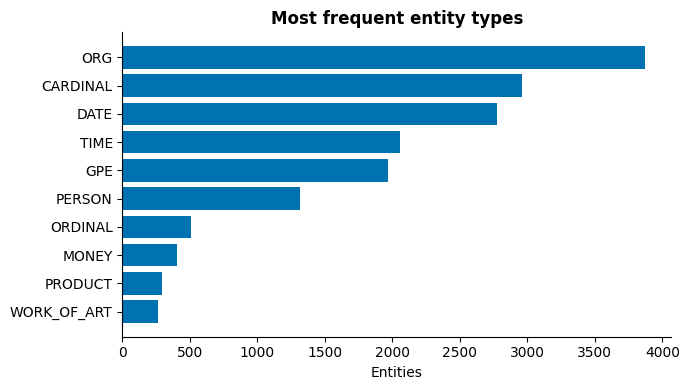

In [ ]:
# entity types with their meaning and count
by_the_Labels = entity_df["Label"].value_counts()
show(pd.DataFrame({"Meaning": [spacy.explain(L) for L in by_the_Labels.index], "Count": by_the_Labels.values},
                  index=by_the_Labels.index), "Entity types:")

# the 10 most frequent types
top = by_the_Labels.head(10)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top.index[::-1], top.values[::-1], color="#0072B2")
ax.set(title="Most frequent entity types", xlabel="Entities")
plt.tight_layout()
plt.show()

In [ ]:
# most frequent entities for six common types
rows = []
for label in ["GPE", "ORG", "DATE", "TIME", "MONEY", "PERSON"]:
    best_Items = entity_df.loc[entity_df["Label"] == label, "Entity"].value_counts().head(6)
    rows.append({"Type": label, "Most frequent entities": ", ".join(f"{e} ({n})" for e, n in best_Items.items())})
show(pd.DataFrame(rows), "Frequent entities by type:")

# six random tweets that have entities
rows = []
for i in entity_df["tweet_index"].drop_duplicates().sample(6, random_state=seed):
    hit = entity_df[entity_df["tweet_index"] == i]
    rows.append({"Tweet": raw_data_Frame.at[i, "ner_text"],
                 "Entities": "; ".join(f"{r.Entity} ({r.Label})" for r in hit.itertuples())})
show(pd.DataFrame(rows), "Example tweets:")

Frequent entities by type:


,Type,Most frequent entities
0,GPE,"US (84), Dallas (78), Boston (75), Denver (73), Chicago (71), Newark (56)"
1,ORG,"DM (136), DFW (112), United (108), PHL (90), SFO (87), ORD (86)"
2,DATE,"today (379), tomorrow (261), yesterday (101), Monday (39), 2 days (34), all day (33)"
3,TIME,"tonight (145), an hour (90), 2 hours (78), this morning (63), 3 hours (50), last night (44)"
4,MONEY,"200 (37), 25 (20), 50 (17), 100 (13), 75 (13), 150 (10)"
5,PERSON,"JFK (136), Twitter (30), Vegas (30), jfk (20), Austin (17), WiFi (16)"


Example tweets:


,Tweet,Entities
0,we had four scheduled flights on this reservation and literally did not take one! Unreal,four (CARDINAL)
1,Flight 395. Rolling delay of 1 hour 42 minutes,1 hour 42 minutes (TIME)
2,this is nuts they said a flight was on the ground now it's still in Albany and they won't have a plane. Someone is compensating me,Albany (GPE)
3,what's with the layover in Canada from the UA125? Is that scheduled?,Canada (GPE); UA125 (PRODUCT)
4,yes I know the industry procedure on baggage. Thanks for helping..... 😉 what about the impossible connection that started this?,😉 (PERSON)
5,flt 1249 Cancelled Flightled and I get email :30 AM? What happened to courtesy phn call? Had to book diff airline & city,1249 (DATE); 30 AM (TIME); airline & city (ORG)


In [ ]:
from spacy.matcher import PhraseMatcher

# service topics and their words, our own choice , the dataset has no such labels
themes = {
    "Delay / cancellation": ["delay", "delayed", "cancelled", "canceled", "cancel", "late"],
    "Baggage": ["bag", "bags", "baggage", "luggage", "suitcase"],
    "Customer service": ["customer service", "customer support", "agent", "hold", "phone", "call"],
    "Refund / payment": ["refund", "charged", "fee", "fees", "credit", "voucher"],
    "Booking / check-in": ["booking", "booked", "check in", "reservation", "ticket", "flight booking"],
    "Seat / boarding": ["seat", "seats", "boarding", "gate"],
    "Wi-Fi / entertainment": ["wifi", "wi fi", "entertainment", "inflight"],
}
# LOWER: the matcher ignores upper and lower case
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
for name, terms in themes.items():
    matcher.add(name, [nlp.make_doc(t) for t in terms])

# a set per tweet, so one topic counts only once per tweet
hits = []
for doc in nlp.tokenizer.pipe(raw_data_Frame["clean_text"], batch_size=512):
    hits.append({nlp.vocab.strings[m] for m, start, end in matcher(doc)})

# per topic: number of tweets, split by sentiment, and the % negative
rows = []
for name in themes:
    mask = pd.Series([name in h for h in hits])
    c = raw_data_Frame.loc[mask, "airline_sentiment"].value_counts().reindex(Class_Orders).fillna(0).astype(int)
    rows.append({"Theme": name, "Tweets": int(mask.sum()), **c.to_dict(),
                 "% negative": round(c["negative"] / max(mask.sum(), 1) * 100, 1)})
show(pd.DataFrame(rows).sort_values("Tweets", ascending=False).reset_index(drop=True), "Service themes:")

Service themes:


,Theme,Tweets,negative,neutral,positive,% negative
0,Delay / cancellation,2060,1824,148,88,88.5
1,Customer service,2005,1733,116,156,86.4
2,Baggage,1098,952,85,61,86.7
3,Seat / boarding,1032,778,143,111,75.4
4,Booking / check-in,801,553,184,64,69.0
5,Refund / payment,472,355,85,32,75.2
6,Wi-Fi / entertainment,147,107,15,25,72.8


The same service topics as a chart: tweets per topic, split by sentiment.

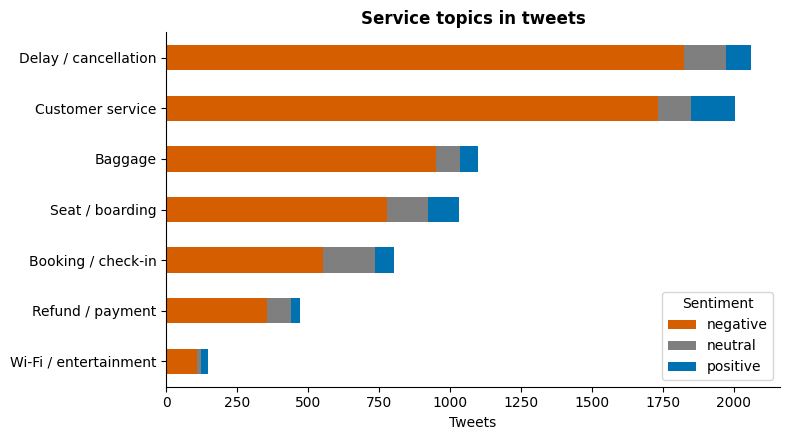

In [ ]:
# tweets per topic and sentiment, from the matcher results above
theme_table = pd.DataFrame({name: raw_data_Frame.loc[pd.Series([name in h for h in hits]), "airline_sentiment"]
                          .value_counts().reindex(Class_Orders).fillna(0).astype(int) for name in themes}).T
# smallest first, so the biggest topic ends up at the top of the chart
theme_table = theme_table.loc[theme_table.sum(axis=1).sort_values().index]

ax = theme_table.plot(kind="barh", stacked=True, figsize=(8, 4.5), color=[COLORS[s] for s in Class_Orders])
ax.set(title="Service topics in tweets", xlabel="Tweets", ylabel="")
ax.legend(title="Sentiment")
plt.tight_layout()
plt.show()

### 1.10 NLTK versus spaCy

Both libraries on the same tweets: tokens, vocabulary, speed and extra features.

In [ ]:
# total number of tokens, and number of different tokens, in a column
def totalNumbers(col):
    return int(raw_data_Frame[col].apply(len).sum())

def vocabNumbers(col):
    return len({t for toks in raw_data_Frame[col] for t in toks})

# one table, same rows for both libraries
compare = pd.DataFrame({
    "NLTK": ["TweetTokenizer (rules)", f"{totalNumbers('nltk_tokens'):,}", f"{totalNumbers('nltk_tokens') / len(raw_data_Frame):.2f}",
             f"{vocabNumbers('nltk_tokens'):,}", f"{totalNumbers('nltk_nostop'):,}", f"{vocabNumbers('nltk_lemmas'):,}",
             f"{vocabNumbers('nltk_stems'):,}", "WordNet lookup, needs a POS hint",
             "Not part of this pipeline", "Many separate tools"],
    "spaCy": ["spaCy tokenizer (rules)", f"{totalNumbers('spacy_tokens'):,}", f"{totalNumbers('spacy_tokens') / len(raw_data_Frame):.2f}",
              f"{vocabNumbers('spacy_tokens'):,}", f"{totalNumbers('spacy_nostop'):,}", f"{vocabNumbers('spacy_lemmas'):,}",
              "No stemmer", "POS-aware, uses the sentence",
              f"Built in: {len(entity_df):,} entities, {entity_df['Label'].nunique()} types",
              "POS tags, parser and NER in one pipeline"],
}, index=["Tokenizer", "Tokens before stop word removal", "Tokens per tweet", "Vocabulary size",
          "Tokens after stop word removal", "Vocabulary after lemmatisation", "Vocabulary after stemming",
          "Lemmatiser", "Named entities", "Other features"])
show(compare, "NLTK vs spaCy:")

NLTK vs spaCy:


,NLTK,spaCy
Tokenizer,TweetTokenizer (rules),spaCy tokenizer (rules)
Tokens before stop word removal,"243,137","244,141"
Tokens per tweet,16.85,16.92
Vocabulary size,"13,015","12,986"
Tokens after stop word removal,"137,889","123,148"
Vocabulary after lemmatisation,"10,765","10,904"
Vocabulary after stemming,"10,196",No stemmer
Lemmatiser,"WordNet lookup, needs a POS hint","POS-aware, uses the sentence"
Named entities,Not part of this pipeline,"Built in: 17,062 entities, 18 types"
Other features,Many separate tools,"POS tags, parser and NER in one pipeline"


### 1.11 Token frequencies, word clouds and bigrams

Most frequent lemmas overall and per class, word clouds, and the most common bigrams in negative tweets. The placeholder `url` is left out.

Top 20 lemmas:


,Lemma,Count
0,flight,4814
1,not,3136
2,get,2085
3,thank,1622
4,no,1482
5,hour,1145
6,cancel,1043
7,u,1013
8,delay,1000
9,service,996


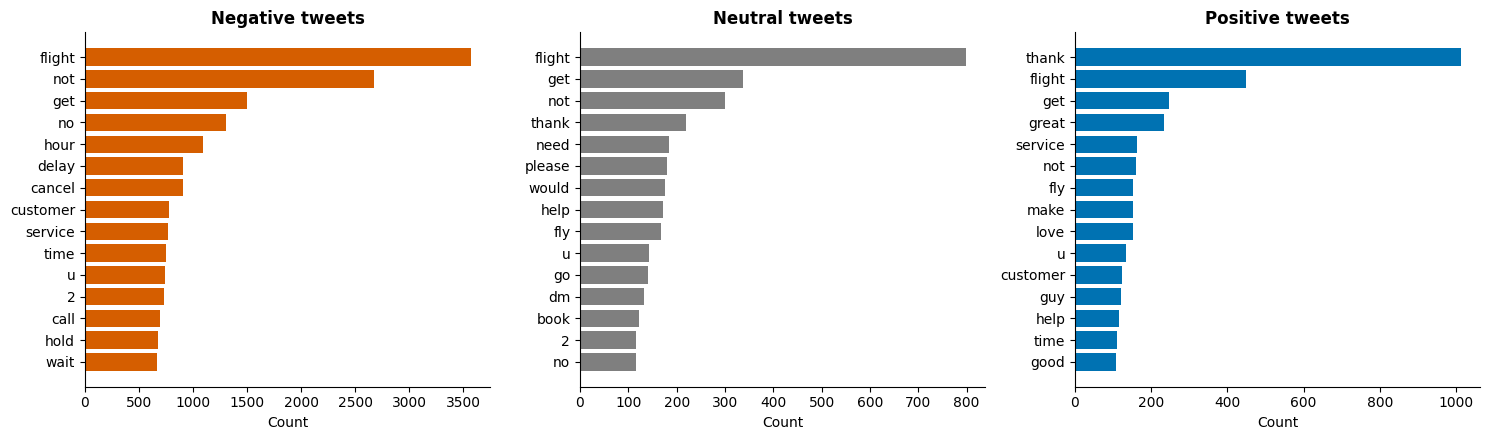

In [ ]:
# "url" is only our own placeholder, so it is left out
raw_data_Frame["freq_lemmas"] = raw_data_Frame["nltk_lemmas"].apply(lambda ls: [l for l in ls if l != "url"])
overall = Counter(l for ls in raw_data_Frame["freq_lemmas"] for l in ls)
show(pd.DataFrame(overall.most_common(20), columns=["Lemma", "Count"]), "Top 20 lemmas:")

# lemma counts per class, shown as three bar charts
class_counts = {CO: Counter(l for rdF in raw_data_Frame.loc[raw_data_Frame["airline_sentiment"] == CO, "freq_lemmas"] for l in rdF)
                for CO in Class_Orders}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, s in zip(axes, Class_Orders):
    words, n = zip(*class_counts[s].most_common(15))
    ax.barh(words[::-1], n[::-1], color=COLORS[s])
    ax.set(title=f"{s.capitalize()} tweets", xlabel="Count")
plt.tight_layout(); plt.show()

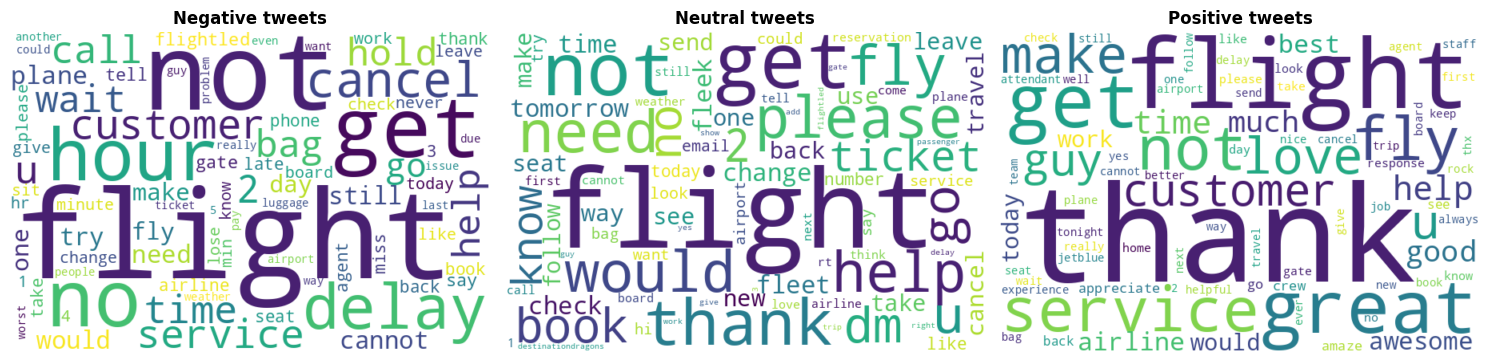

In [ ]:
# one word cloud per class, from the same counts as above
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, s in zip(axes, Class_Orders):
    cloud = WordCloud(width=600, height=400, background_color="white", max_words=80,
                      random_state=seed).generate_from_frequencies(class_counts[s])
    ax.imshow(cloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{s.capitalize()} tweets")
plt.tight_layout()
plt.show()

In [ ]:
# now bigrams in negative tweets, without the url placeholder
# min_df=5: a pair must be appear in atleast 5 tweet
negDocuments = raw_data_Frame.loc[raw_data_Frame["airline_sentiment"] == "negative", "nltk_nostop"].apply(
    lambda ts: " ".join(t for t in ts if t != "url"))
cv = CountVectorizer(ngram_range=(2, 2), min_df=5)
m = cv.fit_transform(negDocuments)
bigrams = pd.DataFrame({"Bigram": cv.get_feature_names_out(), "Count": np.asarray(m.sum(axis=0)).ravel()})
show(bigrams.sort_values("Count", ascending=False).head(15).reset_index(drop=True), "Frequent bigrams in negative tweets:")

Frequent bigrams in negative tweets:


,Bigram,Count
0,customer service,445
1,cancelled flightled,440
2,late flight,218
3,cancelled flighted,198
4,flight cancelled,187
5,late flightr,145
6,no one,125
7,cancelled flight,122
8,call back,104
9,could not,103


### 1.12 A dataset quirk: label names inside tweets

Bigrams like "cancelled flightled" and "late flightr" looks strange for me. It seems those label name (like *Late Flight* or *Cancelled Flight*) are pasted into some tweets, sometimes joined to a word maybe. This cell counts them easiily. Task 2 checks if the classifier uses them as a shortcut or maybe something else.

In [ ]:
# the complaint label names, "Can't Tell" and "longlines" are skipped (not written like label names)
# the pattern also catches the joined forms flightled / flighted / flightr
names = [r for r in raw_data_Frame["negativereason"].dropna().unique() if r not in ("Can't Tell", "longlines")]
leakedPattern = "|".join(re.escape(r) for r in names) + r"|[Ff]light(?:led|ed|r)\b"
raw_data_Frame["label_text"] = raw_data_Frame["text"].str.contains(leakedPattern, regex=True)

# number and share of such tweets in each class
lt = raw_data_Frame.groupby("airline_sentiment")["label_text"].agg(["sum", "mean"]).reindex(Class_Orders)
lt["mean"] = (lt["mean"] * 100).round(1)
lt.columns = ["Tweets with label text", "% of class"]
show(lt, "Tweets that contain label text:")
show(raw_data_Frame.loc[raw_data_Frame["label_text"], ["text", "airline_sentiment"]].head(3), "Examples:")

Tweets that contain label text:


,Tweets with label text,% of class
airline_sentiment,,
negative,1291,14.2
neutral,164,5.4
positive,71,3.1


Examples:


,text,airline_sentiment
30,"@VirginAmerica hi! I just bked a cool birthday trip with you, but i can't add my elevate no. cause i entered my middle name during Flight Booking Problems 😢",negative
82,@VirginAmerica you're the best!! Whenever I (begrudgingly) use any other airline I'm delayed and Late Flight :(,negative
83,@VirginAmerica I have no interesting flying with you after this. I will Cancelled Flight my next four flights I planned.#neverflyvirginforbusiness,negative


### 1.13 Experiment: keep or remove stop words?

One stratified 80/20 split of the cleaned tweets, TF-IDF with Logistic Regression and three versions of the text. It is one split only, so small differences mean little.

In [ ]:
# TF-IDF is inside the pipeline, so it only learns from the training text
def make_model(clf):
    return Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("clf", clf)])

# macro scores count every class equally, accuracy alone would favour the big class
def get_scores(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    wf1 = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)[2]
    return {"Accuracy": round(accuracy_score(y_true, y_pred), 3), "Macro precision": round(p, 3),
            "Macro recall": round(r, 3), "Macro F1": round(f1, 3), "Weighted F1": round(wf1, 3)}

# stratify keeps the class ratio the same in both parts
X_tr, X_te, y_tr, y_te = train_test_split(raw_data_Frame["clean_text"], raw_data_Frame["airline_sentiment"], test_size=0.20,
                                          random_state=seed, stratify=raw_data_Frame["airline_sentiment"])

# removes the given words from a text
def drop_words(text, words):
    return " ".join(t for t in text.split() if t not in words)

# three versions of the input: nothing removed, default NLTK list, list without negations
# each version is trained and tested on the same split
variants = {"Keep all words": set(), "Remove default NLTK list": nltk_original_stopWords, "Remove list, keep negations": nltk_stops_without_negations}
variant_models, rows = {}, []
for name, words in variants.items():
    clf = make_model(LogisticRegression(max_iter=1000, random_state=seed))
    clf.fit(X_tr.apply(lambda s: drop_words(s, words)), y_tr)
    pred = clf.predict(X_te.apply(lambda s: drop_words(s, words)))
    variant_models[name] = (clf, words)
    rows.append({"Variant": name, "Features": len(clf.named_steps["tfidf"].vocabulary_), **get_scores(y_te, pred)})
show(pd.DataFrame(rows).set_index("Variant"), "Stop word handling and a simple classifier:")

Stop word handling and a simple classifier:


,Features,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
Variant,,,,,,
Keep all words,23628,0.805,0.800,0.691,0.730,0.792
Remove default NLTK list,13809,0.784,0.769,0.658,0.695,0.766
"Remove list, keep negations",14432,0.788,0.768,0.669,0.704,0.773


In [ ]:
# four sentences with and without negation, predicted by each version - each sentence gets the same cleaning and word removal as the training text
testSentences = ["the flight was not good", "i will never fly with them again",
         "no problem at all great crew", "the staff was very helpful"]
rows = []
for s in testSentences:
    row = {"Sentence": s}
    for name, (clf, words) in variant_models.items():
        row[name] = clf.predict([drop_words(CleaningTheTweets(s), words)])[0]
    rows.append(row)
show(pd.DataFrame(rows), "Predictions of the three variants:")

Predictions of the three variants:


,Sentence,Keep all words,Remove default NLTK list,"Remove list, keep negations"
0,the flight was not good,negative,negative,negative
1,i will never fly with them again,negative,negative,negative
2,no problem at all great crew,positive,positive,positive
3,the staff was very helpful,positive,negative,positive


### 1.14 Preprocessing decisions for the next tasks

| Step | TF-IDF (Task 2) | Sentence embeddings (Task 3) | DistilBERT (Task 4) |
|---|---|---|---|
| Lowercase, symbols removed | yes, `clean_tweet` | no | no |
| Mentions and links | removed / `url` | removed (`light_clean`) | removed (`light_clean`) |
| Stop words | all kept | all kept | all kept |
| Lemmatisation / stemming | not used | not used | not used |
| Emojis | lost in cleaning | kept | kept |
| Class imbalance | kept, macro metrics, class weights | kept | kept, best checkpoint by macro F1 |



# Task 2: Classical baseline with TF-IDF

### 2.1 One fixed split

A stratified sample of 5,000 tweets is split into 3,000 for training, 1,000 for validation and 1,000 for testing. Tasks 3 and 4 use the same split, so every model is compared on the same data. The class imbalance is left as it is. All tweets outside validation and test form a pool for one extra experiment (2.7).

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix

# stratified at every step, so each part keeps the original class ratio
sample_df, _ = train_test_split(raw_data_Frame, train_size=5000, random_state=seed, stratify=raw_data_Frame["airline_sentiment"])
train_df, rest = train_test_split(sample_df, train_size=3000, random_state=seed, stratify=sample_df["airline_sentiment"])
val_df, test_df = train_test_split(rest, train_size=1000, random_state=seed, stratify=rest["airline_sentiment"])
# everything outside validation and test, used only in 2.7
pool_df = raw_data_Frame.drop(index=list(val_df.index) + list(test_df.index))

# cleaned text (input) and sentiment (label) of each part
X_train, y_train = train_df["clean_text"], train_df["airline_sentiment"]
X_val, y_val = val_df["clean_text"], val_df["airline_sentiment"]
X_test, y_test = test_df["clean_text"], test_df["airline_sentiment"]

# tweets per class in each part
split = pd.DataFrame({"Train": y_train.value_counts(), "Validation": y_val.value_counts(),
                      "Test": y_test.value_counts()}).reindex(Class_Orders)
split.loc["Total"] = split.sum()
show(split, "Tweets per class:")
print("Extra pool (outside validation and test:", len(pool_df))

Tweets per class:


,Train,Validation,Test
airline_sentiment,,,
negative,1888,629,630
neutral,635,212,212
positive,477,159,158
Total,3000,1000,1000


Extra pool (outside validation and test: 12427


### 2.2 Compare classical models on the validation set

Four classifiers on the same TF-IDF features (word 1-2 grams, `min_df=2`) and a majority-class reference. "Balanced" gives the smaller classes more weight. The best model is picked by validation macro F1, so the test set is not touched before 2.3.

In [ ]:
# majority class is the reference every model has to beat

# class_weight : "balanced" wil gives the two smaller classes more weight
classical = {
    "Majority class (reference)": make_model(DummyClassifier(strategy="most_frequent")),
    "Logistic Regression": make_model(LogisticRegression(max_iter=1000, random_state=seed)),
    "Logistic Regression (balanced)": make_model(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)),
    "Linear SVM (balanced)": make_model(LinearSVC(class_weight="balanced", random_state=seed)),
    "Complement Naive Bayes": make_model(ComplementNB()),
}

# train each model and score it on the validation set (training time is saved too)
rows, secs = [], {}
for name, model in classical.items():
    T = time.time()
    model.fit(X_train, y_train)
    secs[name] = time.time() - T
    rows.append({"Model": name, **get_scores(y_val, model.predict(X_val)), "Train seconds": round(secs[name], 2)})
val_table = pd.DataFrame(rows).set_index("Model")
show(val_table, "Validation results:")

# the choice is made on validation only, the reference is not a candidate
best_name = val_table.drop(index="Majority class (reference)")["Macro F1"].idxmax()
print("Best on validation (macro F1):", best_name)

Validation results:


,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1,Train seconds
Model,,,,,,
Majority class (reference),0.629,0.210,0.333,0.257,0.486,0.53
Logistic Regression,0.753,0.771,0.585,0.626,0.718,4.22
Logistic Regression (balanced),0.769,0.701,0.702,0.701,0.768,0.96
Linear SVM (balanced),0.772,0.715,0.675,0.690,0.762,0.25
Complement Naive Bayes,0.755,0.732,0.603,0.633,0.724,0.21


Best on validation (macro F1): Logistic Regression (balanced)


### 2.3 Final evaluation on the test set

Scores of the chosen model, classification report and confusion matrix (counts and % of each true class). Training time, prediction time and number of features are kept for the comparison in Task 4.

Test scores:


,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
Logistic Regression (balanced),0.782,0.719,0.729,0.724,0.784


Classification report:


,precision,recall,f1-score,support
negative,0.875,0.854,0.864,630.000
neutral,0.593,0.618,0.605,212.000
positive,0.689,0.715,0.702,158.000
accuracy,0.782,0.782,0.782,0.782
macro avg,0.719,0.729,0.724,1000.000
weighted avg,0.786,0.782,0.784,1000.000


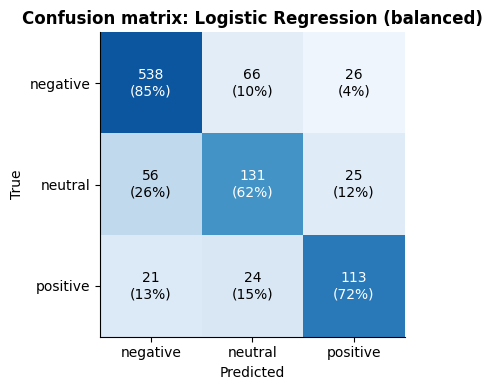

Train 0.96 s | predict 1000 tweets 0.053 s | 7375 features (about 22128 weights)


In [ ]:
# confusion matrix as counts and as % of each true class

# the % is what shows the weak classes, counts alone hide them
def plotConfusionMatrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=Class_Orders)
    pct = cm / cm.sum(axis=1, keepdims=True) * 100
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i, j]}\n({pct[i, j]:.0f}%)", ha="center", va="center",
                    color="white" if pct[i, j] > 50 else "black")
    ax.set(xticks=range(3), yticks=range(3), xticklabels=Class_Orders, yticklabels=Class_Orders,
           xlabel="Predicted", ylabel="True", title=title)
    plt.tight_layout(); plt.show()

best_Items = classical[best_name]
T = time.time()
test_pred = best_Items.predict(X_test)
predict_secs = time.time() - T

# first and only time the test set is used for this model
show(pd.DataFrame([get_scores(y_test, test_pred)], index=[best_name]), "Test scores:")
report = classification_report(y_test, test_pred, labels=Class_Orders, output_dict=True, zero_division=0)
show(pd.DataFrame(report).T.round(3), "Classification report:")
plotConfusionMatrix(y_test, test_pred, f"Confusion matrix: {best_name}")

# size of the model: one weight per feature and class, plus one bias per class
n_feat = len(best_Items.named_steps["tfidf"].vocabulary_)
print(f"Train {secs[best_name]:.2f} s | predict 1000 tweets {predict_secs:.3f} s | {n_feat} features (about {n_feat * 3 + 3} weights)")

### 2.4 Error analysis

Which classes get mixed up, how errors relates to anotator agreement (confidence 1.0 means all annotators agreed) and which complaint reasons will missed mostly. Then single tweets and the words with the highest will weights.

In [ ]:
# one row per test tweet, with the prediction and a right/wrong flag
errors = test_df[["text", "clean_text", "airline_sentiment", "airline_sentiment_confidence", "negativereason"]].copy()
errors["predicted"] = test_pred
errors["wrong"] = errors["airline_sentiment"] != errors["predicted"]
print("Wrong predictions:", int(errors["wrong"].sum()), "of", len(errors))

# true class ==> predicted class, most common mistakes first
pairs = errors[errors["wrong"]].groupby(["airline_sentiment", "predicted"]).size().sort_values(ascending=False)
show(pairs.rename("Tweets").reset_index().rename(columns={"airline_sentiment": "true", "predicted": "predicted"}),
     "Most common confusions:")

# error rate when all annotators agreed against of when they did not
errors["agreement"] = np.where(errors["airline_sentiment_confidence"] >= 1.0, "1.00 (full agreement)", "below 1.00")
confusion = errors.groupby("agreement")["wrong"].agg(["count", "mean"])
confusion["mean"] = (confusion["mean"] * 100).round(1)
confusion.columns = ["Tweets", "Error rate %"]
show(confusion, "Error rate by annotator agreement:")

# negative tweets that were missed, grouped by complaint reason
missed = errors[errors["airline_sentiment"] == "negative"].groupby("negativereason")["wrong"].agg(["count", "mean"])
missed["mean"] = (missed["mean"] * 100).round(1)
missed.columns = ["Negative tweets", "Missed %"]
show(missed.sort_values("Missed %", ascending=False), "Negative tweets that were missed, by reason:")

Wrong predictions: 218 of 1000
Most common confusions:


,true,predicted,Tweets
0,negative,neutral,66
1,neutral,negative,56
2,negative,positive,26
3,neutral,positive,25
4,positive,neutral,24
5,positive,negative,21


Error rate by annotator agreement:


,Tweets,Error rate %
agreement,,
1.00 (full agreement),728,15.0
below 1.00,272,40.1


Negative tweets that were missed, by reason:


,Negative tweets,Missed %
negativereason,,
Damaged Luggage,3,66.7
Can't Tell,82,32.9
Flight Booking Problems,38,26.3
Bad Flight,50,20.0
Lost Luggage,52,11.5
Customer Service Issue,174,9.8
Flight Attendant Complaints,32,9.4
Late Flight,119,9.2
Cancelled Flight,65,7.7


In [ ]:
# complaints that the model called neutral or positive
missedNegatives = errors[(errors["airline_sentiment"] == "negative") & errors["wrong"]]
show(missedNegatives[["text", "predicted", "airline_sentiment_confidence", "negativereason"]]
     .sample(min(6, len(missedNegatives)), random_state=seed), "Complaints predicted as neutral or positive:")

# neutral or positive tweets that the model called negative
falseNegatives = errors[(errors["airline_sentiment"] != "negative") & (errors["predicted"] == "negative")]
show(falseNegatives[["text", "airline_sentiment", "airline_sentiment_confidence"]]
     .sample(min(4, len(falseNegatives)), random_state=seed), "Neutral or positive tweets predicted as negative:")

Complaints predicted as neutral or positive:


,text,predicted,airline_sentiment_confidence,negativereason
4254,"@united I was denied use of a rear facing car seat on UA5025, an ERJ145. Can you confirm the actual policy?",neutral,1.0000,Customer Service Issue
6848,@JetBlue you can do better than this. And you can do better for me and all the passengers. #flight108 jfk to pwm.,neutral,0.6570,Can't Tell
12963,@AmericanAir I'm trying to make a reservation with a &lt; 2 year old lap child. Don't see any option online. How do I proceed with reservation?,neutral,0.6546,Flight Booking Problems
12805,@AmericanAir attached original ticket. flight number was 1672. isn't the experience I thought I would have. Terrible! http://t.co/5SdlyN9MSS,neutral,1.0000,Can't Tell
14172,"@AmericanAir please fix your inventory system, Plat upgraded then bumped DOWN after boarding, FA said they made a mistake. AA45 3A➡️8C 😕",neutral,1.0000,Can't Tell
3962,"@united yup, it just happens way too often...5 times in the last 12 months",neutral,1.0000,Late Flight


Neutral or positive tweets predicted as negative:


,text,airline_sentiment,airline_sentiment_confidence
11221,@USAirways just noticed that I don't believe I saw a confirmation for a flight I bought a few weeks ago. Def paid though. #help #resend?,neutral,1.0000
10867,@USAirways call Gate D9 in CLT and get me on this flight,neutral,1.0000
1677,@united AND WE GOT ZERO VOUCHERS FOR HOTEL OR CAB. I expect some SERIOUS mileage credits.,neutral,0.6117
3156,@united 4 reFlight Booking Problemss in last 2 days and each time united wait time was &lt;5 seconds! Kudos to you for excellent customer service!,positive,1.0000


In [ ]:
# weights of the balanced Logistic Regression, the 10 highest words per their class
LogisticRegression_var = classical["Logistic Regression (balanced)"]
words = np.array(LogisticRegression_var.named_steps["tfidf"].get_feature_names_out())
coefs = LogisticRegression_var.named_steps["clf"].coef_
top_words = {c: words[np.argsort(coefs[i])[::-1][:10]] for i, c in enumerate(LogisticRegression_var.named_steps["clf"].classes_)}
show(pd.DataFrame(top_words), "Ten highest-weighted words per class:")

Ten highest-weighted words per class:


,negative,neutral,positive
0,not,can,thanks
1,no,url,great
2,hours,can you,thanks for
3,delayed,is it,thank you
4,cancelled,any,awesome
5,hold,tomorrow,thank
6,hour,number,love
7,on hold,is your,amazing
8,that,or,good
9,worst,do you,always


### 2.5 Does the label text from 1.12 matters?

Test tweets with label text are compareing with the rest. Then the same model is trained again after the label text is cut out of all tweeters. If the scores barely change, the model is not using it as a shortcut.

In [ ]:
# accuracy and negative recall, with and without label text
errors["label_text"] = raw_data_Frame.loc[errors.index, "label_text"]
rows = []
for flag, g in errors.groupby("label_text"):
    Negs = g[g["airline_sentiment"] == "negative"]
    rows.append({"Contains label text": "yes" if flag else "no", "Test tweets": len(g),
                 "Accuracy": round((~g["wrong"]).mean(), 3),
                 "Negative recall": round((Negs["predicted"] == "negative").mean(), 3) if len(Negs) else np.nan})
show(pd.DataFrame(rows), "Test tweets with and without label text:")

# cut the label text (and letters joined to it, like the r in Flightr), then clean again
# same model, trained again on the stripped text
Striped = raw_data_Frame["text"].str.replace(r"(?:" + leakedPattern + r")(?:led|ed|r)?\b", " ", regex=True).apply(CleaningTheTweets)
predictStripped = clone(best_Items).fit(Striped.loc[train_df.index], y_train).predict(Striped.loc[test_df.index])
show(pd.DataFrame([{"Text": "Original", **get_scores(y_test, test_pred)},
                   {"Text": "Label text removed", **get_scores(y_test, predictStripped)}]).set_index("Text"),
     "Effect of removing the label text:")

Test tweets with and without label text:


,Contains label text,Test tweets,Accuracy,Negative recall
0,no,884,0.770,0.836
1,yes,116,0.871,0.957


Effect of removing the label text:


,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
Text,,,,,
Original,0.782,0.719,0.729,0.724,0.784
Label text removed,0.769,0.705,0.720,0.712,0.772


### 2.6 Optional: NER features

Seven yes/no flags from the NER in Task 1 (does the tweet have a GPE, ORG, DATE, TIME, MONEY, PERSON or CARDINAL entity?) are added to the TF-IDF matrix. Same balanced Logistic Regression, compared on the validation set.

In [ ]:
# 1 if the tweet has at least one entity of that type, otherwise 0
types = ["GPE", "ORG", "DATE", "TIME", "MONEY", "PERSON", "CARDINAL"]
counts_by_type = pd.crosstab(entity_df["tweet_index"], entity_df["Label"]).reindex(index=raw_data_Frame.index, columns=types, fill_value=0)
flags = (counts_by_type > 0).astype(int)

# TF-IDF learns from the training text only, then the flags are added as an extra columns also
TF_IDF_var = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
A_train = TF_IDF_var.fit_transform(X_train)
A_val = TF_IDF_var.transform(X_val)
B_train = hstack([A_train, csr_matrix(flags.loc[train_df.index].values)])
B_val = hstack([A_val, csr_matrix(flags.loc[val_df.index].values)])

# same model with and without flags
rows = []
for name, tr, va in [("TF-IDF only", A_train, A_val), ("TF-IDF + NER flags", B_train, B_val)]:
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed).fit(tr, y_train)
    rows.append({"Features": name, **get_scores(y_val, clf.predict(va))})
show(pd.DataFrame(rows).set_index("Features"), "NER features (validation set):")

NER features (validation set):


,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
Features,,,,,
TF-IDF only,0.769,0.701,0.702,0.701,0.768
TF-IDF + NER flags,0.760,0.687,0.693,0.689,0.759


### 2.7 Extra: does more training data help?

The chosen model is trained again on the whole pool (all tweets outside validation and test) and tested on the same 1,000 test tweets.

In [ ]:
# same model, same test set, only the training data will be bigger
big = clone(best_Items)
T = time.time()
big.fit(pool_df["clean_text"], pool_df["airline_sentiment"])
big_secs = time.time() - T

show(pd.DataFrame([
    {"Training tweets": len(train_df), **get_scores(y_test, test_pred), "Train seconds": round(secs[best_name], 2)},
    {"Training tweets": len(pool_df), **get_scores(y_test, big.predict(X_test)), "Train seconds": round(big_secs, 2)},
]), f"{best_name}: 3,000 tweets vs the whole pool (same test set):")

Logistic Regression (balanced): 3,000 tweets vs the whole pool (same test set):


,Training tweets,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1,Train seconds
0,3000,0.782,0.719,0.729,0.724,0.784,0.96
1,12427,0.803,0.743,0.768,0.754,0.806,6.48


# Task 3: Semantic embeddings

### 3.1 Create the embeddings

With about 14,000 short tweets, Word2Vec trained from scratch would see too little text. So a pretrained sentence model ("all-MiniLM-L6-v2", 384 dimensions) embeds each full tweet directly. The input is the lightly cleaned text, so emojis, capitals and negations stay. The vectors are normalised to length 1, and they are compared with cosine similarit aswll.

In [ ]:
from sentence_transformers import SentenceTransformer

# light text for the model, the heavy text only if nothing is left after light cleaning
raw_data_Frame["model_text"] = raw_data_Frame["ner_text"].where(raw_data_Frame["ner_text"] != "", raw_data_Frame["clean_text"])
SentenceTransformerModel = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Device:", SentenceTransformerModel.device)

# normalising vectors the last number printed below is the check
# time for comparing in task 4

T = time.time()
emb = SentenceTransformerModel.encode(raw_data_Frame["model_text"].tolist(), batch_size=128, normalize_embeddings=True, show_progress_bar=False)
emb_secs = time.time() - T
print(f"Embedding matrix {emb.shape} in {emb_secs:.1f} s | length of first vector: {np.linalg.norm(emb[0]):.3f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Device: cuda:0
Embedding matrix (14427, 384) in 9.2 s | length of first vector: 1.000


### 3.2 Cosine similarity of example sentences

Seven pairs: same meaning in different words, different topics, and opposite meanings.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# embed two sentences and return their cosine similarity
def CosineSimilarityFunc(a, b):
    v = SentenceTransformerModel.encode([a, b], normalize_embeddings=True)
    return float(cosine_similarity(v[0:1], v[1:2])[0, 0])

pairs = [
    ("My flight was delayed for hours", "The plane left much later than planned", "Same meaning"),
    ("They lost my luggage", "My bag never arrived", "Same meaning"),
    ("The customer service was unhelpful", "Nobody at the support desk could help me", "Same meaning"),
    ("My flight was delayed for hours", "The cabin crew were friendly", "Different topics"),
    ("They lost my luggage", "I love the new seats", "Different topics"),
    ("My flight was delayed", "My flight was on time", "Opposite meaning"),
    ("The service was great", "The service was terrible", "Opposite meaning"),
]
show(pd.DataFrame([{"Sentence 1": a, "Sentence 2": b, "Relationship": rel, "Cosine similarity": round(CosineSimilarityFunc(a, b), 3)}
                   for a, b, rel in pairs]), "Cosine similarity of sentence pairs:")

Cosine similarity of sentence pairs:


,Sentence 1,Sentence 2,Relationship,Cosine similarity
0,My flight was delayed for hours,The plane left much later than planned,Same meaning,0.429
1,They lost my luggage,My bag never arrived,Same meaning,0.578
2,The customer service was unhelpful,Nobody at the support desk could help me,Same meaning,0.276
3,My flight was delayed for hours,The cabin crew were friendly,Different topics,0.191
4,They lost my luggage,I love the new seats,Different topics,0.232
5,My flight was delayed,My flight was on time,Opposite meaning,0.789
6,The service was great,The service was terrible,Opposite meaning,0.741


### 3.3 PCA and t-SNE

1,500 random tweeters are drawn in two dimensions and colored by sentiment. A second t-SNE shows 300 negatives tweeters for each of the five most common complaint reasons ("Can't Tell" is skipped, it is not a topic). The silhouette score uses the full 384 dimensions and cosine distance. A value near zero means the groups overlap a lot.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

Variance explained by the 2 PCA components: 9.6 %


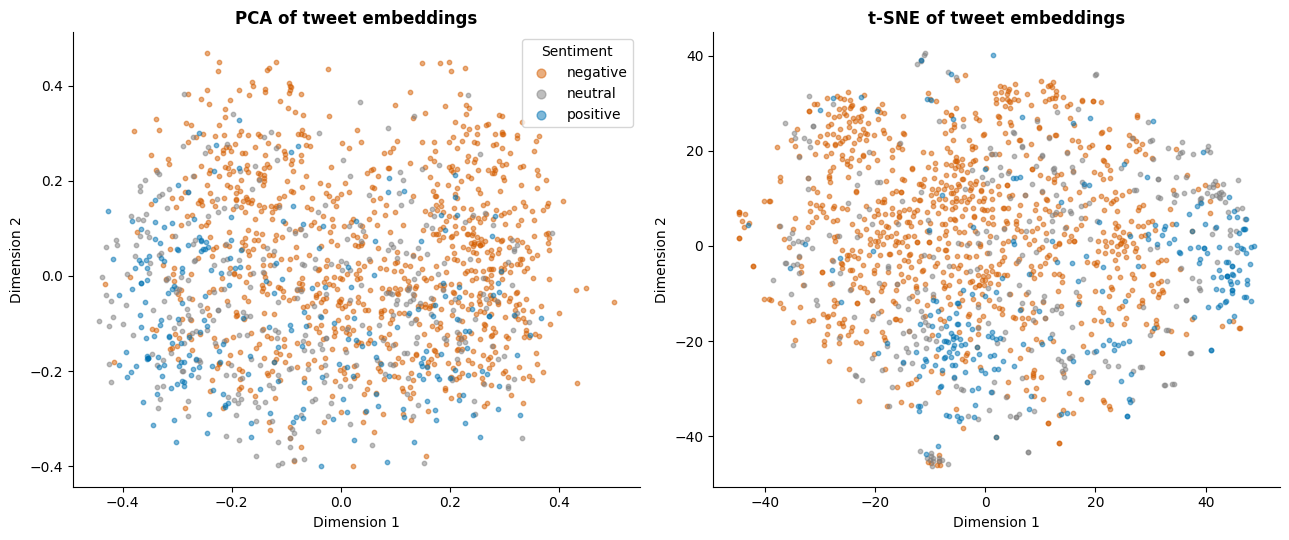

Silhouette (sentiment, 384-d): 0.036


In [ ]:
# 1,500 random tweets, PCA and t-SNE both start from the full vectors
idx = raw_data_Frame.sample(1500, random_state=seed).index.values
vecs, labels = emb[idx], raw_data_Frame.loc[idx, "airline_sentiment"].values


# init equls "pca" will makes t-SNE more stable between runs
pca = PCA(n_components=2, random_state=seed)
pca_pts = pca.fit_transform(vecs)
print("Variance explained by the 2 PCA components:", round(float(pca.explained_variance_ratio_.sum()) * 100, 1), "%")
tsne_pts = TSNE(n_components=2, perplexity=30, init="pca", random_state=seed).fit_transform(vecs)

# both plots side by side, colored by sentiment
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pts, name in [(axes[0], pca_pts, "PCA"), (axes[1], tsne_pts, "t-SNE")]:
    for s in Class_Orders:
        mask = labels == s
        ax.scatter(pts[mask, 0], pts[mask, 1], s=10, alpha=0.5, color=COLORS[s], label=s)
    ax.set(title=f"{name} of tweet embeddings", xlabel="Dimension 1", ylabel="Dimension 2")
axes[0].legend(title="Sentiment", markerscale=2)
plt.tight_layout()
plt.show()

# silhouette on the original 384 dimensions, not on the 2-d points
print("Silhouette (sentiment, 384-d):", round(float(silhouette_score(vecs, labels, metric="cosine")), 3))

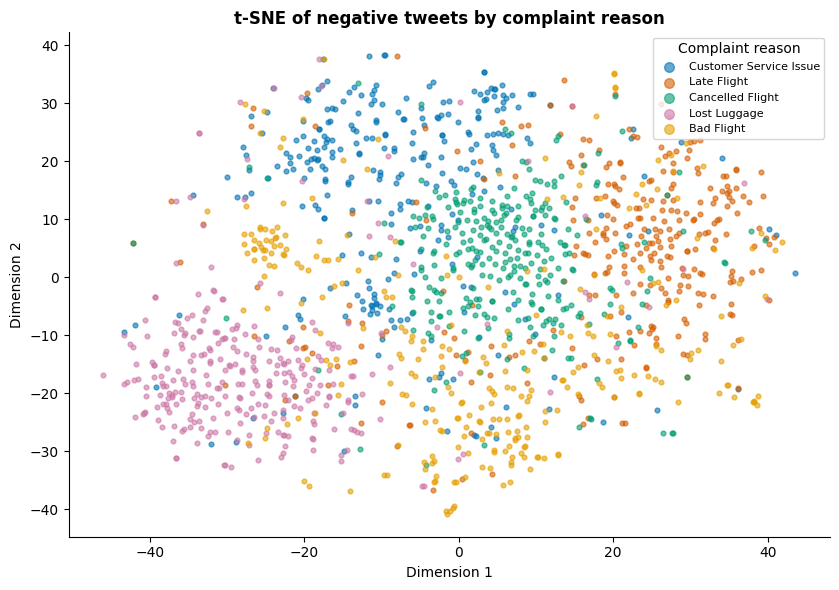

Silhouette (complaint reason, 384-d): 0.028


In [ ]:
# five most common complaint reasons ("Can't Tell" is not a topic), 300 tweets each
top_reasons = raw_data_Frame.loc[raw_data_Frame["negativereason"] != "Can't Tell", "negativereason"].value_counts().head(5).index.tolist()
rawSample = raw_data_Frame[raw_data_Frame["negativereason"].isin(top_reasons)].groupby("negativereason", group_keys=False).sample(300, random_state=seed)
r_vecs = emb[rawSample.index.values]
r_pts = TSNE(n_components=2, perplexity=30, init="pca", random_state=seed).fit_transform(r_vecs)

# one colour per reason
fig, ax = plt.subplots(figsize=(8.5, 6))
for reason, color in zip(top_reasons, ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]):
    mask = (rawSample["negativereason"] == reason).values
    ax.scatter(r_pts[mask, 0], r_pts[mask, 1], s=12, alpha=0.6, color=color, label=reason)
ax.set(title="t-SNE of negative tweets by complaint reason", xlabel="Dimension 1", ylabel="Dimension 2")
ax.legend(title="Complaint reason", markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

print("Silhouette (complaint reason, 384-d):",
      round(float(silhouette_score(r_vecs, rawSample["negativereason"].values, metric="cosine")), 3))

### 3.4 Retrieving similar complaints

The query is embedded and all tweets are ranked by cosine similarity. For comparison, a keyword search ranks the tweets by TF-IDF similarity on the cleaned text.

In [ ]:
# keyword searching ==> TF-IDF vectors of the cleaned tweets
keywordVectorizer = TfidfVectorizer(ngram_range=(1, 2))
keywordMatrix = keywordVectorizer.fit_transform(raw_data_Frame["clean_text"])

# the k best tweets for a score array, with their score
def topTweeters(scores, k):
    best_idx = np.argsort(-scores)[:k]
    out = raw_data_Frame.iloc[best_idx][["text", "airline_sentiment", "negativereason"]].copy()
    out.insert(0, "score", scores[best_idx].round(3))
    return out

# cosine similarity of the query with every tweet at once
def semantic_Search(query, k=5):
    query = SentenceTransformerModel.encode(query, normalize_embeddings=True).reshape(1, -1)
    return topTweeters(cosine_similarity(emb, query).ravel(), k)

# the query gets the same cleaning as the tweets
def keyword_search(query, k=5):
    query = keywordVectorizer.transform([CleaningTheTweets(query)])
    return topTweeters(cosine_similarity(keywordMatrix, query).ravel(), k)

# two example queries, both searches
for query in ["delivery was late", "customer service was unhelpful"]:
    show(semantic_Search(query), f"Semantic search: {query!r}")
    show(keyword_search(query), f"Keyword search: {query!r}")

Semantic search: 'delivery was late'


,score,text,airline_sentiment,negativereason
3663,0.590,"@united Not sure what happened @ MSP yesterday, but VERY UNHAPPY my bag was not only delayed, but sat at MSP for 8 hrs b4 delivery @ 2:30 am",negative,Lost Luggage
14091,0.569,@AmericanAir delayed.....wow,negative,Late Flight
14348,0.567,"@AmericanAir Not only was 5418 Late Flight, but we've been boarded and waiting for over 30min. WTF?",negative,Late Flight
12799,0.566,@AmericanAir thanks. Delivery status??,positive,NaN
8198,0.557,@JetBlue delayed flight bummer,negative,Late Flight


Keyword search: 'delivery was late'


,score,text,airline_sentiment,negativereason
12799,0.268,@AmericanAir thanks. Delivery status??,positive,NaN
11171,0.241,@USAirways phone support rebooked but orig flt was Late Flight. Made it!,negative,Customer Service Issue
537,0.216,"@united See? We were told repeatedly that the pilot was Late Flight and kept getting Late Flightr. After we boarded, there was a defibrillator issue.",negative,Late Flight
11166,0.210,@USAirways our hold up now is the captain that was Late Flight...his bag doesn't fit.,negative,Late Flight
2570,0.203,@united - you delayed our departure by 2 hrs to wait for passengers from another flight that was Late Flight! Unacceptable!!,negative,Late Flight


Semantic search: 'customer service was unhelpful'


,score,text,airline_sentiment,negativereason
13543,0.703,@AmericanAir your customer service is a disgrace.,negative,Customer Service Issue
10018,0.688,@USAirways not impressed with your customer service. everyone has been unhelpful and incredibly rude.,negative,Customer Service Issue
11801,0.688,@USAirways your customer service is horrible,negative,Customer Service Issue
2974,0.687,@united your customer service is terrible,negative,Customer Service Issue
10688,0.686,@USAirways worst customer service experience ever today. Get it together.,negative,Customer Service Issue


Keyword search: 'customer service was unhelpful'


,score,text,airline_sentiment,negativereason
4170,0.526,@united customer service 👎,negative,Customer Service Issue
10022,0.256,@USAirways WORST customer service ever!!!,negative,Customer Service Issue
1725,0.253,@united so unhelpful... http://t.co/vBfIeo2qJC,negative,Customer Service Issue
3089,0.252,@united it's a shame the great customer service wasn't continued in SFO. Slightly absurd,negative,Customer Service Issue
11310,0.248,"@USAirways Joined Silver Preferred because I heard customer service was so great, pity I was misguided.",negative,Customer Service Issue


Precision@k checks the top results automatically. A result counts as relevant if its human complaint reason matches the topic of the query. This is a rough proxy and six queries are few, so the table is only a hint.

In [ ]:
# six queries and the complaint reason each one should find
six_queries = {
    "my flight was delayed for hours": "Late Flight",
    "the plane left hours after the scheduled time": "Late Flight",
    "customer service was unhelpful": "Customer Service Issue",
    "they lost my luggage": "Lost Luggage",
    "my flight was cancelled": "Cancelled Flight",
    "the flight attendant was rude": "Flight Attendant Complaints",
}

# share of the top k results whose complaint reason is the wanted one
def p_at(result, reason, k):
    return float((result["negativereason"].head(k) == reason).mean())

rows = []
for q, reason in six_queries.items():
    sem, kw = semantic_Search(q), keyword_search(q)
    rows.append({"Query": q, "Wanted reason": reason,
                 "Semantic P@3": p_at(sem, reason, 3), "Semantic P@5": p_at(sem, reason, 5),
                 "Keyword P@3": p_at(kw, reason, 3), "Keyword P@5": p_at(kw, reason, 5)})
prec = pd.DataFrame(rows).set_index("Query")
prec.iloc[:, 1:] = prec.iloc[:, 1:].round(2)
# last row: average over the six queries
prec.loc["Average"] = [""] + prec.iloc[:, 1:].astype(float).mean().round(2).tolist()
show(prec, "Precision@k (complaint reason as relevance):")

Precision@k (complaint reason as relevance):


,Wanted reason,Semantic P@3,Semantic P@5,Keyword P@3,Keyword P@5
Query,,,,,
my flight was delayed for hours,Late Flight,0.67,0.80,0.67,0.60
the plane left hours after the scheduled time,Late Flight,0.33,0.40,0.67,0.40
customer service was unhelpful,Customer Service Issue,1.00,1.00,1.00,1.00
they lost my luggage,Lost Luggage,1.00,1.00,1.00,1.00
my flight was cancelled,Cancelled Flight,1.00,0.80,1.00,1.00
the flight attendant was rude,Flight Attendant Complaints,1.00,1.00,0.33,0.40
Average,,0.83,0.83,0.78,0.73


### 3.5 Extra: can frozen embeddings classify sentiment?

A balanced Logistic Regression on the 384-dimensional vectors (the embedding model is not trained), same split as Task 2, compared with the TF-IDF model.

In [ ]:
# embeddings of each part, same rows as train / validation / test
E_train, E_val, E_test = (emb[d.index.values] for d in (train_df, val_df, test_df))

# the embedding model stays frozen, only this classifier is trained
emb_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
T = time.time()
emb_clf.fit(E_train, y_train)
emb_fit_secs = time.time() - T
emb_val_pred, emb_test_pred = emb_clf.predict(E_val), emb_clf.predict(E_test)

show(pd.DataFrame([
    {"Model": f"TF-IDF + {best_name} (Task 2)", "Set": "Test", **get_scores(y_test, test_pred)},
    {"Model": "MiniLM + Logistic Regression (balanced)", "Set": "Validation", **get_scores(y_val, emb_val_pred)},
    {"Model": "MiniLM + Logistic Regression (balanced)", "Set": "Test", **get_scores(y_test, emb_test_pred)},
]), "TF-IDF vs frozen embeddings:")
print(f"Classifier training: {emb_fit_secs:.2f} s (embedding all tweets took {emb_secs:.1f} s)")

emb_report = classification_report(y_test, emb_test_pred, labels=Class_Orders, output_dict=True, zero_division=0)
show(pd.DataFrame(emb_report).T.round(3), "Classification report (embeddings, test set):")

TF-IDF vs frozen embeddings:


,Model,Set,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression (balanced) (Task 2),Test,0.782,0.719,0.729,0.724,0.784
1,MiniLM + Logistic Regression (balanced),Validation,0.771,0.704,0.733,0.717,0.776
2,MiniLM + Logistic Regression (balanced),Test,0.778,0.719,0.760,0.734,0.786


Classifier training: 0.58 s (embedding all tweets took 9.2 s)
Classification report (embeddings, test set):


,precision,recall,f1-score,support
negative,0.920,0.802,0.857,630.000
neutral,0.560,0.731,0.634,212.000
positive,0.678,0.747,0.711,158.000
accuracy,0.778,0.778,0.778,0.778
macro avg,0.719,0.760,0.734,1000.000
weighted avg,0.805,0.778,0.786,1000.000


# Task 4: Fine-tuning DistilBERT

### 4.1 Setup

Standard fine-tuning settings: learning rate 2e-5, batch size 16, weight decay 0.01, 10% warm-up, fp16 on GPU. For this data there are three labels, and macro F1 (not accuracy) picks the best checkpoint. Training runs for up to 10 epochs, bcs in a first run with 2 epochs the validation score was still rising also. The best epoch is picked on the validation set. please Use GPU runtime.

In [ ]:
import torch, inspect, math, transformers
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding,
                          Trainer, TrainingArguments, set_seed)

# same seed for torch, numpy and transformers
set_seed(seed)

# fp16 (faster, less memory) only works on a GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16 = torch.cuda.is_available()
print("transformers", transformers.__version__, "| torch", torch.__version__, "| device", DEVICE)


transformers 5.17.0 | torch 2.11.0+cu130 | device cuda


### 4.2 Prepare and tokenise the data

Same train, validation and test tweets as in Task 2, using the lightly cleaned `model_text`. Labels become numbers (0 negative, 1 neutral, 2 positive). Tweets are cut at 256 tokens and padded per batch, not to a fixed length.

In [ ]:
# label names and numbers
Label2ID = {name: i for i, name in enumerate(Class_Orders)}
Id2Label = {i: name for name, i in Label2ID.items()}
raw_data_Frame["label"] = raw_data_Frame["airline_sentiment"].map(Label2ID)

# model_text and label of one split as a Hugging Face dataset
def make_dataset(split):
    part = raw_data_Frame.loc[split.index, ["model_text", "label"]].rename(columns={"model_text": "text"})
    return Dataset.from_pandas(part, preserve_index=False)

MODEL_NAME, MAX_LEN = "distilbert-base-uncased", 256
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# no padding here
def tokenizeFunc(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

tokenizeTrain, tokenizeVal, tokenizeTest = (make_dataset(d).map(tokenizeFunc, batched=True) for d in (train_df, val_df, test_df))
collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Train / validation / test:", len(tokenizeTrain), len(tokenizeVal), len(tokenizeTest))

# tweet length in tokens, and how many tweets are cut at MAX_LEN
lengths = np.array([len(x) for x in tokenizeTrain["input_ids"]])
print(f"Tokens per tweet: mean {lengths.mean():.1f}, 95th percentile {int(np.percentile(lengths, 95))}, "
      f"max {lengths.max()}, cut at {MAX_LEN}: {int((lengths >= MAX_LEN).sum())}")

# one example of the word pieces, the emoji becomes [UNK] (unknown)
example_sentences = "@united my flight was delayed again!!! can't believe it 😡"
print(tokenizer.convert_ids_to_tokens(tokenizer(LightCleaningTheTweets(example_sentences))["input_ids"]))

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train / validation / test: 3000 1000 1000
Tokens per tweet: mean 24.0, 95th percentile 37, max 48, cut at 256: 0
['[CLS]', 'my', 'flight', 'was', 'delayed', 'again', '!', '!', '!', 'can', "'", 't', 'believe', 'it', '[UNK]', '[SEP]']


### 4.3 Load the pretrained model

DistilBERT with a new classification head for three labels. The head starts with random weights.

In [ ]:
# pretrained DistilBERT + new classification head with 3 outputs
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=Id2Label, label2id=Label2ID).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} parameters | labels: {model.config.id2label}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


66,955,779 parameters | labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


### 4.4 Metrics and training arguments

The Trainer reports accuracy, macro precision, macro recall, macro F1 and weighted F1 after each epoch. Argument names differ between `transformers` versions, so the code checks which ones the installed version has.

In [ ]:
# macro F1 picks the best epoch, accuracy alone would favour the big negative class
def computeMetrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, pred, average="macro", zero_division=0)
    wf1 = precision_recall_fscore_support(labels, pred, average="weighted", zero_division=0)[2]
    return {"accuracy": accuracy_score(labels, pred), "macro_precision": p, "macro_recall": r,
            "macro_f1": f1, "weighted_f1": wf1}

# maximum number of epochs, the best one is picked on validation (see 4.5)
EPOCHS = 10

# arguments that the installed versions accept
ta_params = inspect.signature(TrainingArguments.__init__).parameters
tr_params = inspect.signature(Trainer.__init__).parameters

# plain cross-entropy loss, no class weights
# the best checkpoint (by macro F1) is loaded at the end
args = {
    "output_dir": "distilbert_airline", "learning_rate": 2e-5,
    "per_device_train_batch_size": 16, "per_device_eval_batch_size": 32,
    "num_train_epochs": EPOCHS, "weight_decay": 0.01,
    "save_strategy": "epoch", "logging_steps": 25, "save_total_limit": 1,
    "load_best_model_at_end": True, "metric_for_best_model": "macro_f1", "greater_is_better": True,
    "fp16": USE_FP16, "seed": seed, "data_seed": seed, "report_to": "none", "optim": "adamw_torch",
}
# the name changed between versions (eval_strategy / evaluation_strategy)
args["eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"] = "epoch"
# warmup_ratio, or the same 10% as a number of steps in older versions
if "warmup_ratio" in ta_params:
    args["warmup_ratio"] = 0.10
else:
    args["warmup_steps"] = round(math.ceil(len(tokenizeTrain) / 16) * EPOCHS * 0.10)

# newer versions call it processing_class, older ones tokenizer
trainer_args = {"model": model, "args": TrainingArguments(**args), "train_dataset": tokenizeTrain,
                "eval_dataset": tokenizeVal, "data_collator": collator, "compute_metrics": computeMetrics}
trainer_args["processing_class" if "processing_class" in tr_params else "tokenizer"] = tokenizer
trainer = Trainer(**trainer_args)
print("fp16:", USE_FP16)

fp16: True


### 4.5 Fine-tune

Training time and GPU memory are recorded. At the end the checkpoint with the best validation macro F1 is loaded. The table and chart after training show if the score has stopped improving.

In [ ]:
# train, and we keep the time for the comparison in 4.7
T = time.time()
trainer.train()
bert_train_secs = time.time() - T
print(f"\nTraining time: {bert_train_secs:.0f} s | best checkpoint: {trainer.state.best_model_checkpoint}")
print("Best validation macro F1:", round(trainer.state.best_metric, 4))
if torch.cuda.is_available():
    print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.590943,0.537390,0.791000,0.729932,0.694182,0.702751,0.779245
2,0.421393,0.493249,0.824000,0.773859,0.751828,0.759476,0.818407
3,0.276083,0.550478,0.818000,0.760030,0.752836,0.751292,0.812688
4,0.168254,0.736631,0.807000,0.759985,0.715705,0.729453,0.795528
5,0.143109,0.827480,0.802000,0.746172,0.746400,0.745677,0.804077
6,0.101419,0.905590,0.821000,0.767763,0.752853,0.756792,0.815620
7,0.050207,0.941661,0.818000,0.762725,0.741334,0.750118,0.813160
8,0.031848,0.976761,0.821000,0.771351,0.749703,0.759237,0.817062
9,0.024311,1.004325,0.819000,0.763074,0.750733,0.755596,0.815571
10,0.006902,1.007061,0.820000,0.764859,0.753348,0.758065,0.816953


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training time: 206 s | best checkpoint: distilbert_airline/checkpoint-376
Best validation macro F1: 0.7595
Peak GPU memory: 1.46 GB


Validation metrics per epoch:


,epoch,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1
0,1.0,0.5374,0.791,0.7299,0.6942,0.7028
1,2.0,0.4932,0.824,0.7739,0.7518,0.7595
2,3.0,0.5505,0.818,0.7600,0.7528,0.7513
3,4.0,0.7366,0.807,0.7600,0.7157,0.7295
4,5.0,0.8275,0.802,0.7462,0.7464,0.7457
5,6.0,0.9056,0.821,0.7678,0.7529,0.7568
6,7.0,0.9417,0.818,0.7627,0.7413,0.7501
7,8.0,0.9768,0.821,0.7714,0.7497,0.7592
8,9.0,1.0043,0.819,0.7631,0.7507,0.7556
9,10.0,1.0071,0.820,0.7649,0.7533,0.7581


Best epoch (validation macro F1): 2 of 10


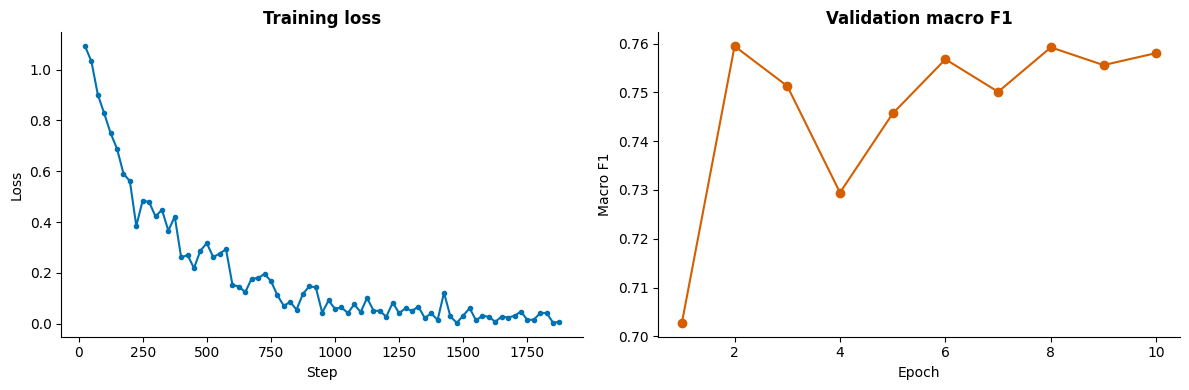

In [ ]:
# validation metrics after each epoch, taken from the training log
hist = pd.DataFrame(trainer.state.log_history)
ev = hist[hist["eval_loss"].notna()] if "eval_loss" in hist else hist.iloc[0:0]
show(ev[["epoch", "eval_loss", "eval_accuracy", "eval_macro_precision", "eval_macro_recall", "eval_macro_f1"]]
     .round(4).reset_index(drop=True), "Validation metrics per epoch:")
if len(ev):
    print("Best epoch (validation macro F1):", int(ev.loc[ev["eval_macro_f1"].idxmax(), "epoch"]), "of", EPOCHS)

# training loss every 25 steps, and validation macro F1 after each epoch
tl = hist[hist["loss"].notna()] if "loss" in hist else hist.iloc[0:0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tl["step"], tl["loss"], marker="o", markersize=3, color="#0072B2")
axes[0].set(title="Training loss", xlabel="Step", ylabel="Loss")
axes[1].plot(ev["epoch"], ev["eval_macro_f1"], marker="o", color="#D55E00")
axes[1].set(title="Validation macro F1", xlabel="Epoch", ylabel="Macro F1")
plt.tight_layout()
plt.show()

### 4.6 Test set evaluation

The test tweets are predicted once. Logits become class names and, through softmax, probabilities. The probabilities are used in 4.8 and in Task 5.

Test scores:


,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
DistilBERT (fine tuned),0.825,0.779,0.77,0.774,0.824


Classification report:


,precision,recall,f1-score,support
negative,0.883,0.902,0.892,630.000
neutral,0.673,0.642,0.657,212.000
positive,0.781,0.766,0.773,158.000
accuracy,0.825,0.825,0.825,0.825
macro avg,0.779,0.770,0.774,1000.000
weighted avg,0.823,0.825,0.824,1000.000


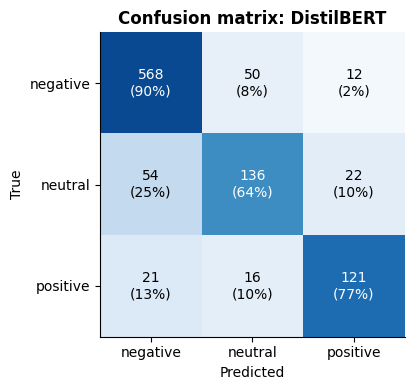

Prediction time for 1000 tweets: 0.49 s


In [ ]:
T = time.time()
out = trainer.predict(tokenizeTest)
bert_predict_secs = time.time() - T

# logits -> class names, and softmax -> confidence (used in 4.8 and Task 5)
logits = out.predictions
bert_pred = np.array([Id2Label[i] for i in logits.argmax(axis=1)])
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

show(pd.DataFrame([get_scores(y_test, bert_pred)], index=["DistilBERT (fine tuned)"]), "Test scores:")
bert_report = classification_report(y_test, bert_pred, labels=Class_Orders, output_dict=True, zero_division=0)
show(pd.DataFrame(bert_report).T.round(3), "Classification report:")
plotConfusionMatrix(y_test, bert_pred, "Confusion matrix: DistilBERT")
print(f"Prediction time for 1000 tweets: {bert_predict_secs:.2f} s")

### 4.7 Comparison with the classical models

The three models on the same 1,000 test tweets: the TF-IDF model (Task 2), frozen MiniLM embeddings with Logistic Regression (3.5) and fine-tuned DistilBERT. The MiniLM prediction time includes encoding the test tweets.

In [ ]:
# MiniLM prediction time = encoding the test tweets + the classifier

T = time.time()
emb_clf.predict(SentenceTransformerModel.encode(raw_data_Frame.loc[test_df.index, "model_text"].tolist(), batch_size=128,
                                normalize_embeddings=True, show_progress_bar=False))
emb_pred_secs = time.time() - T
STparams = sum(p.numel() for p in SentenceTransformerModel.parameters())

# parameters: TF-IDF model = its weights, MiniLM = encoder + classifier, DistilBERT = whole model
rows = [
    {"Model": f"TF-IDF + {best_name}", **get_scores(y_test, test_pred), "Training seconds": round(secs[best_name], 1),
     "Prediction seconds": round(predict_secs, 2), "Parameters": n_feat * 3 + 3},
    {"Model": "MiniLM + Logistic Regression (balanced)", **get_scores(y_test, emb_test_pred),
     "Training seconds": round(emb_fit_secs, 1), "Prediction seconds": round(emb_pred_secs, 2),
     "Parameters": STparams + 384 * 3 + 3},
    {"Model": "DistilBERT (fine tuned)", **get_scores(y_test, bert_pred), "Training seconds": round(bert_train_secs, 1),
     "Prediction seconds": round(bert_predict_secs, 2), "Parameters": n_params},
]
show(pd.DataFrame(rows).set_index("Model"), "Comparison on the same test tweets:")

# F1 of each class, taken from the three reports
f1_per_class = pd.DataFrame({
    "TF-IDF + LR": [report[c]["f1-score"] for c in Class_Orders],
    "MiniLM + LR": [emb_report[c]["f1-score"] for c in Class_Orders],
    "DistilBERT": [bert_report[c]["f1-score"] for c in Class_Orders]}, index=Class_Orders).round(3)
show(f1_per_class, "F1 per class (test set):")

Comparison on the same test tweets:


,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1,Training seconds,Prediction seconds,Parameters
Model,,,,,,,,
TF-IDF + Logistic Regression (balanced),0.782,0.719,0.729,0.724,0.784,1.0,0.05,22128
MiniLM + Logistic Regression (balanced),0.778,0.719,0.760,0.734,0.786,0.6,0.38,22714371
DistilBERT (fine tuned),0.825,0.779,0.770,0.774,0.824,206.3,0.49,66955779


F1 per class (test set):


,TF-IDF + LR,MiniLM + LR,DistilBERT
negative,0.864,0.857,0.892
neutral,0.605,0.634,0.657
positive,0.702,0.711,0.773


### 4.8 Error patterns, missed complaints and confidence

The two models side by side: who is right when they disagree (exact McNemar test), which complaint reasons each one misses, and after that , whether the confidence of DistilBERT can decide which tweets go to a human reviewer.

In [ ]:
from scipy.stats import binomtest

# one table with both predictions and the DistilBERT confidence
cmp = errors[["text", "airline_sentiment", "airline_sentiment_confidence", "negativereason"]].copy()
cmp["tfidf_pred"], cmp["bert_pred"], cmp["bert_conf"] = test_pred, bert_pred, probs.max(axis=1)
tfidf_ok = (cmp["tfidf_pred"] == cmp["airline_sentiment"]).values
bert_ok = (cmp["bert_pred"] == cmp["airline_sentiment"]).values

# who is right when the two models disagree
agree = pd.Series({"Both correct": (tfidf_ok & bert_ok).sum(), "Only DistilBERT correct": (~tfidf_ok & bert_ok).sum(),
                   "Only TF-IDF correct": (tfidf_ok & ~bert_ok).sum(), "Both wrong": (~tfidf_ok & ~bert_ok).sum()},
                  name="Tweets").astype(int)
show(agree.to_frame(), "Agreement of the two models:")
# McNemar: only the tweets where exactly one model is right count
b, c = agree["Only DistilBERT correct"], agree["Only TF-IDF correct"]
print("Exact McNemar test, p-value:", format(binomtest(b, b + c, 0.5).pvalue, ".3g"))

# % of negative tweets each model misses, per complaint reason (reasons with 20+ tweets)
neg_t = cmp[cmp["airline_sentiment"] == "negative"].assign(
    tfidf_miss=lambda d: (d["tfidf_pred"] != "negative") * 100,
    bert_miss=lambda d: (d["bert_pred"] != "negative") * 100)
tab = neg_t.groupby("negativereason").agg(**{"Negative tweets": ("text", "count"),
                                             "TF-IDF missed %": ("tfidf_miss", "mean"),
                                             "DistilBERT missed %": ("bert_miss", "mean")})
show(tab[tab["Negative tweets"] >= 20].round(1).sort_values("Negative tweets", ascending=False),
     "Missed complaints by reason (reasons with 20+ tweets):")

Agreement of the two models:


,Tweets
Both correct,714
Only DistilBERT correct,111
Only TF-IDF correct,68
Both wrong,107


Exact McNemar test, p-value: 0.00162
Missed complaints by reason (reasons with 20+ tweets):


,Negative tweets,TF-IDF missed %,DistilBERT missed %
negativereason,,,
Customer Service Issue,174,9.8,6.3
Late Flight,119,9.2,6.7
Can't Tell,82,32.9,19.5
Cancelled Flight,65,7.7,3.1
Lost Luggage,52,11.5,15.4
Bad Flight,50,20.0,16.0
Flight Booking Problems,38,26.3,18.4
Flight Attendant Complaints,32,9.4,3.1


In [ ]:
# is the model less sure when it is wrong?
print("Mean DistilBERT confidence when correct:", round(float(cmp.loc[bert_ok, "bert_conf"].mean()), 3))
print("Mean DistilBERT confidence when wrong:  ", round(float(cmp.loc[~bert_ok, "bert_conf"].mean()), 3))

# below the threshold a tweet goes to a person instead of being handled automatically
rows = []
for thr in [0.0, 0.6, 0.7, 0.8, 0.9]:
    auto = cmp["bert_conf"].values >= thr
    rows.append({"Confidence threshold": thr, "Handled automatically %": round(auto.mean() * 100, 1),
                 "Accuracy of automatic tweets": round(bert_ok[auto].mean(), 3),
                 "Sent to human review": int((~auto).sum()),
                 "Wrong predictions caught %": round((~auto & ~bert_ok).sum() / (~bert_ok).sum() * 100, 1)})
show(pd.DataFrame(rows), "Human review rule based on DistilBERT confidence:")

Mean DistilBERT confidence when correct: 0.889
Mean DistilBERT confidence when wrong:   0.727
Human review rule based on DistilBERT confidence:


,Confidence threshold,Handled automatically %,Accuracy of automatic tweets,Sent to human review,Wrong predictions caught %
0,0.0,100.0,0.825,0,0.0
1,0.6,91.8,0.853,82,22.9
2,0.7,83.2,0.886,168,45.7
3,0.8,75.0,0.911,250,61.7
4,0.9,56.6,0.947,434,82.9


In [ ]:
# four tweets from the Task 2 error analysis, now with both predictions wil be considered
ids = [i for i in [4254, 3962, 8800, 9863] if i in cmp.index]
show(cmp.loc[ids, ["text", "airline_sentiment", "tfidf_pred", "bert_pred", "bert_conf"]].round(3),
     "Tweets from the Task 2 error analysis:")

# the mistakes DistilBERT was most sure about them
show(cmp[~bert_ok].sort_values("bert_conf", ascending=False).head(4)
     [["text", "airline_sentiment", "bert_pred", "bert_conf", "airline_sentiment_confidence"]].round(3),
     "Most confident mistakes of DistilBERT:")

Tweets from the Task 2 error analysis:


,text,airline_sentiment,tfidf_pred,bert_pred,bert_conf
4254,"@united I was denied use of a rear facing car seat on UA5025, an ERJ145. Can you confirm the actual policy?",negative,neutral,neutral,0.505
3962,"@united yup, it just happens way too often...5 times in the last 12 months",negative,neutral,negative,0.841
8800,@JetBlue we don't need anybody else!,positive,negative,negative,0.881
9863,@USAirways But good luck getting there! Not cool.,neutral,positive,positive,0.879


Most confident mistakes of DistilBERT:


,text,airline_sentiment,bert_pred,bert_conf,airline_sentiment_confidence
8263,@JetBlue I can't. I don't have acces to a phone rn. My iPhone broke. :/ would rather change it now then Late Flightr.,neutral,negative,0.975,1.00
12327,@AmericanAir just hoping/praying for a safe flight. They've had to stop and de-ice our plane yet again😞,neutral,negative,0.971,1.00
12931,@AmericanAir no. Prebook flight for wife's 40th bday in NO. I recently have had surgery and can't travel. Won't let another go in my place,neutral,negative,0.961,1.00
7858,@JetBlue real shit my nigga north don't play around!,neutral,negative,0.957,0.65


# Extension: sentiment-aware retrieval

In 3.2 opposite sentences came out close together, so a search for *The service was great* can return complaints. A simple fix: take the 50 most similar tweets (cosine), keep only those that DistilBERT predicts with the wanted sentiment, and return the first five. DistilBERT first predicts the sentiment of all tweets. It was trained on about a fifth of them, so the check below (human labels, eight queries) is only a hint.

In [ ]:
# predicted sentiment of all tweets
allDataset = Dataset.from_pandas(raw_data_Frame[["model_text"]].rename(columns={"model_text": "text"}),
                             preserve_index=False).map(tokenizeFunc, batched=True)
raw_data_Frame["bert_sentiment"] = [Id2Label[i] for i in trainer.predict(allDataset).predictions.argmax(axis=1)]
show(raw_data_Frame["bert_sentiment"].value_counts().reindex(Class_Orders).rename("Tweets").to_frame(), "Predicted sentiment of all tweets:")

# topic first (cosine), then sentiment (DistilBERT prediction)
def SentmentSearch(query, wanted, k=5, n_candidates=50):
    cand = semantic_Search(query, k=n_candidates)
    cand["predicted_sentiment"] = raw_data_Frame.loc[cand.index, "bert_sentiment"]
    return cand[cand["predicted_sentiment"] == wanted].head(k)

Map:   0%|          | 0/14427 [00:00<?, ? examples/s]

Predicted sentiment of all tweets:


,Tweets
bert_sentiment,
negative,9421
neutral,2721
positive,2285


In [ ]:
# eight queries and the sentiment each one should find
polarity = {
    "My flight was on time": "positive", "My flight was delayed": "negative",
    "The service was great": "positive", "The service was terrible": "negative",
    "the crew was friendly and helpful": "positive", "worst airline ever": "negative",
    "thank you for the quick help": "positive", "they lost my bag": "negative",
}
# how many of the top 5 really have the wanted sentiment (human labels), plain vs hybrid
rows = []
for q, wanted in polarity.items():
    plain, hybrid = semantic_Search(q), SentmentSearch(q, wanted)
    rows.append({"Query": q, "Wanted sentiment": wanted,
                 "Plain search (of 5)": int((plain["airline_sentiment"] == wanted).sum()),
                 "Hybrid search (of 5)": int((hybrid["airline_sentiment"] == wanted).sum())})
pol = pd.DataFrame(rows).set_index("Query")
pol.loc["Average share correct"] = ["", round(pol["Plain search (of 5)"].mean() / 5, 2),
                                    round(pol["Hybrid search (of 5)"].mean() / 5, 2)]
show(pol, "Top 5 results with the wanted sentiment (human labels):")

Top 5 results with the wanted sentiment (human labels):


,Wanted sentiment,Plain search (of 5),Hybrid search (of 5)
Query,,,
My flight was on time,positive,1.00,1.00
My flight was delayed,negative,5.00,5.00
The service was great,positive,4.00,5.00
The service was terrible,negative,5.00,5.00
the crew was friendly and helpful,positive,4.00,5.00
worst airline ever,negative,5.00,5.00
thank you for the quick help,positive,4.00,4.00
they lost my bag,negative,5.00,5.00
Average share correct,,0.82,0.88


In [ ]:
# the two searches side by side for two queries
for q in ["The service was great", "My flight was on time"]:
    show(semantic_Search(q), f"Plain search: {q!r}")
    show(SentmentSearch(q, "positive"), f"Hybrid search: {q!r}")
# how many of the 50 candidates are predicted positive for the on-time query
print("Candidates predicted positive (of 50) for 'My flight was on time':",
      len(SentmentSearch("My flight was on time", "positive", k=50)))

Plain search: 'The service was great'


,score,text,airline_sentiment,negativereason
5731,0.655,@SouthwestAir was fantastic! That's the best flight service I've ever had.,positive,NaN
9153,0.647,@USAirways terrible service,negative,Can't Tell
2545,0.618,@united service by staff was great as usual. Cleanliness and smells a bit much. I'll be back. #satisfied traveler,positive,NaN
12849,0.602,@AmericanAir great job and great service in and out of SDF this weekend during the winter storm.,positive,NaN
9431,0.594,@USAirways it was customer service like I have never seen before! Kudos to your organization.,positive,NaN


Hybrid search: 'The service was great'


,score,text,airline_sentiment,negativereason,predicted_sentiment
5731,0.655,@SouthwestAir was fantastic! That's the best flight service I've ever had.,positive,NaN,positive
2545,0.618,@united service by staff was great as usual. Cleanliness and smells a bit much. I'll be back. #satisfied traveler,positive,NaN,positive
12849,0.602,@AmericanAir great job and great service in and out of SDF this weekend during the winter storm.,positive,NaN,positive
9431,0.594,@USAirways it was customer service like I have never seen before! Kudos to your organization.,positive,NaN,positive
6510,0.592,@SouthwestAir your employees were great!,positive,NaN,positive


Plain search: 'My flight was on time'


,score,text,airline_sentiment,negativereason
5464,0.712,@SouthwestAir great flight got us back on time! Thanks,positive,NaN
11116,0.707,@USAirways thanks for telling me my flight was on time when the plane was broken. You're an inferior airline.,negative,Can't Tell
12306,0.705,@AmericanAir I was rebooked on a flight that was too Late Flight for my connection!,negative,Cancelled Flight
573,0.704,"@united in addition, my first flight was delayed an hour and I'm arriving at my destination 8 hrs Late Flight.",negative,Late Flight
11043,0.700,@USAirways 4 hours Late Flightr And i lost my conection 😡,negative,Late Flight


Hybrid search: 'My flight was on time'


,score,text,airline_sentiment,negativereason,predicted_sentiment
5464,0.712,@SouthwestAir great flight got us back on time! Thanks,positive,NaN,positive


Candidates predicted positive (of 50) for 'My flight was on time': 1


# Task 5: Responsible NLP checks on our own results

Numbers for the discussion in the report: how the models behave for each airline, how many urgent complaints are missed, and how much personal data and abusive language is in the tweets.

### 5.1 are the models work equally well for every airline?

Airline is only a stand-in for groups, the dataset has no demographic data. It still shows if accuracy and the share predicted as negative differ between groups.

In [ ]:
# p_neg ==> probability DistilBERT give to the negative class
fair = cmp.assign(airline=raw_data_Frame.loc[cmp.index, "airline"], p_neg=probs[:, Label2ID["negative"]])

# results per airline on the test set
rows = []
for airline, g in fair.groupby("airline"):
    rows.append({
        "Airline": airline, "Test tweets": len(g),
        "True negative %": round((g["airline_sentiment"] == "negative").mean() * 100, 1),
        "Predicted negative % (DistilBERT)": round((g["bert_pred"] == "negative").mean() * 100, 1),
        "TF-IDF accuracy": round((g["tfidf_pred"] == g["airline_sentiment"]).mean(), 3),
        "DistilBERT accuracy": round((g["bert_pred"] == g["airline_sentiment"]).mean(), 3),
        "DistilBERT macro F1": round(precision_recall_fscore_support(
            g["airline_sentiment"], g["bert_pred"], average="macro", zero_division=0)[2], 3)})
show(pd.DataFrame(rows).set_index("Airline"), "Results by airline (test set):")

Results by airline (test set):


,Test tweets,True negative %,Predicted negative % (DistilBERT),TF-IDF accuracy,DistilBERT accuracy,DistilBERT macro F1
Airline,,,,,,
American,179,75.4,72.1,0.821,0.866,0.802
Delta,142,33.8,40.8,0.683,0.775,0.775
Southwest,170,42.9,50.0,0.776,0.806,0.793
US Airways,205,78.0,77.1,0.834,0.873,0.758
United,271,74.2,73.4,0.768,0.804,0.699
Virgin America,33,39.4,42.4,0.818,0.788,0.774


### 5.2 Urgent complaints and the cost of a lower threshold

"Urgent" is our own definition: cancelled or late flights, lost or damaged luggage and booking problems. First, how many of them each model misses. Then a rule for DistilBERT that favours recall: flag a tweet when P(negative) reaches a threshold below 0.5.

In [ ]:
# our own definition of urgent, the dataset has no such label
urgent_reasons = ["Cancelled Flight", "Lost Luggage", "Damaged Luggage", "Flight Booking Problems", "Late Flight"]
is_complaint = (fair["airline_sentiment"] == "negative").values
is_urgent = is_complaint & fair["negativereason"].isin(urgent_reasons).values
print("Complaints in the test set:", int(is_complaint.sum()), "| urgent:", int(is_urgent.sum()))

# urgent complaints that each model does not predict as negative
rows = []
for name, pred in [("TF-IDF + Logistic Regression", fair["tfidf_pred"]), ("DistilBERT", fair["bert_pred"])]:
    missed = (pred.values != "negative") & is_urgent
    rows.append({"Model": name, "Urgent complaints": int(is_urgent.sum()), "Missed": int(missed.sum()),
                 "Missed %": round(missed.sum() / is_urgent.sum() * 100, 1)})
show(pd.DataFrame(rows).set_index("Model"), "Urgent complaints missed:")

# lower threshold = fewer missed complaints, but more false alarms
rows = []
for thr in [0.5, 0.4, 0.3, 0.2, 0.1]:
    flagged = fair["p_neg"].values >= thr
    rows.append({"Threshold for P(negative)": thr,
                 "Urgent complaints found %": round(flagged[is_urgent].mean() * 100, 1),
                 "All complaints found %": round(flagged[is_complaint].mean() * 100, 1),
                 "Non-complaints flagged %": round(flagged[~is_complaint].mean() * 100, 1),
                 "All tweets flagged %": round(flagged.mean() * 100, 1)})
show(pd.DataFrame(rows).set_index("Threshold for P(negative)"), "Threshold: missed complaints vs false alarms (DistilBERT):")

Complaints in the test set: 630 | urgent: 277
Urgent complaints missed:


,Urgent complaints,Missed,Missed %
Model,,,
TF-IDF + Logistic Regression,277,34,12.3
DistilBERT,277,26,9.4


Threshold: missed complaints vs false alarms (DistilBERT):


,Urgent complaints found %,All complaints found %,Non-complaints flagged %,All tweets flagged %
Threshold for P(negative),,,,
0.5,89.9,89.4,18.9,63.3
0.4,93.1,91.7,21.6,65.8
0.3,94.9,94.0,26.8,69.1
0.2,96.4,95.4,33.8,72.6
0.1,99.3,98.4,49.2,80.2


### 5.3 Privacy signals and abusive language

Simple patterns count the tweets with an email address, a phone number, several mentions or a link. The NER from Task 1 adds person names. The abusive word list is short on purpose, so the counts are a lower bound.

In [ ]:
# patterns for personal data signals
patterns = {
    "Email address": r"[\w.+-]+@[\w-]+\.[a-zA-Z]{2,}",
    "Phone number": r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b",
    "More than one @mention": r"@\w+.*@\w+",
    "Link": r"https?://\S+",
}
# share of tweets with each signal, and with a person name found by NER
rows = [{"Signal": k, "Tweets %": round(raw_data_Frame["text"].str.contains(p, regex=True).mean() * 100, 1)} for k, p in patterns.items()]
person = entity_df.loc[entity_df["Label"] == "PERSON", "tweet_index"].nunique() / len(raw_data_Frame) * 100
rows.append({"Signal": "Person name (spaCy NER)", "Tweets %": round(person, 1)})
show(pd.DataFrame(rows).set_index("Signal"), "Personal data signals:")

# short list on purpose, so these counts are lower bound
abusive = r"\b(?:wtf|fuck\w*|shit\w*|bullshit|damn\w*|crap\w*|idiot\w*|stupid|asshole\w*|suck\w*|hell)\b"
raw_data_Frame["abusive"] = raw_data_Frame["text"].str.contains(abusive, case=False, regex=True)
# number and share of abusive tweets in each class
ab = raw_data_Frame.groupby("airline_sentiment")["abusive"].agg(["sum", "mean"]).reindex(Class_Orders)
ab["mean"] = (ab["mean"] * 100).round(1)
ab.columns = ["Abusive tweets", "% of class"]
show(ab, "Tweets with abusive words:")

Personal data signals:


,Tweets %
Signal,
Email address,0.1
Phone number,0.2
More than one @mention,10.8
Link,8.1
Person name (spaCy NER),8.5


Tweets with abusive words:


,Abusive tweets,% of class
airline_sentiment,,
negative,309,3.4
neutral,10,0.3
positive,7,0.3


In [ ]:
# is DistilBERT works bad on tweets with abusive words?
fair["abusive"] = raw_data_Frame.loc[fair.index, "abusive"]
rows = []
for flag, g in fair.groupby("abusive"):
    rows.append({"Abusive words": "yes" if flag else "no", "Test tweets": len(g),
                 "True negative %": round((g["airline_sentiment"] == "negative").mean() * 100, 1),
                 "DistilBERT accuracy": round((g["bert_pred"] == g["airline_sentiment"]).mean(), 3)})
show(pd.DataFrame(rows).set_index("Abusive words"), "DistilBERT with and without abusive words (test set):")

DistilBERT with and without abusive words (test set):


,Test tweets,True negative %,DistilBERT accuracy
Abusive words,,,
no,972,62.1,0.823
yes,28,92.9,0.893
